# Kunitz Domain Prediction

stepsThis project aims to obtain a Hidden Markov Model (HMM) for predicting the presence of proteins belonging to the Kunitz family (Pfam: PF00014). The process involves several key steps:
1.  **Data Acquisition**: Querying the RCSB PDB for relevant protein structures.
2.  **Data Cleaning and Preparation**: Filtering and formatting the retrieved data.
3.  **Clustering**: Grouping similar protein sequences using MMseqs2.
4.  **Multiple Alignment**: Aligning representative protein structures using mTM-align.
5.  **HMM Construction**: Building a Hidden Markov Model with HMMER from the multiple alignment.
6.  **Model Evaluation**: Assessing the HMM's performance using cross-validation and a custom script.

## Data Acquisition

First, we need to download the report from PDB including the proteins of interest.

For that we go to [https://www.rcsb.org](https://www.rcsb.org), select **Advanced Search** and build a query with the next elements:

- **Pfam ID is PF00014**, so we're selecting just proteins that are part of the Kunitz domain.
- **Resolution <= 3.5 Å**, so we're picking proteins that are well structurally resolved.
- **Polymer Entity Sequence Length ≥ 45** and
- **Polymer Entity Sequence Length ≤ 80**, following the assignment criterion: 45 ≤ Polymer Entity Sequence Length ≤ 80.

We then select the button **Tabular Reports**, and under the menu **Select Report** we pick **Custom Report**. Among the whole list of options, we go to the **Polymer Entity Data** column and tick the options:

- **Entity ID**, the PDB ID of the protein.
- **Auth Asym ID**, containing the ID of each chain associated to the domain, and the
- **Sequence**, under the *Entity Source Organism* section.

With that, we clicked the **Run Report** button and we have now a table, which we download with the **CSV** format.

We can then save it in Drive, and copy it into the notebook environment by running this cell:

In [268]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [269]:
!cp -r "/content/drive/MyDrive/Kunitz-BPTI-HMM" "/content/"

In [270]:
import os

project_dir = "/content/Kunitz-BPTI-HMM"
os.chdir(project_dir)

print("Current folder:", os.getcwd())

Current folder: /content/Kunitz-BPTI-HMM


The PDB report was parsed with Python. Entry ID, chain ID and sequence were extracted, missing PDB IDs were forward-filled, and only protein sequences with length between 45 and 80 amino acids, inclusive, were retained. This follows the assignment criterion: 45 ≤ Polymer Entity Sequence Length ≤ 80. Exact duplicate PDB:chain entries were removed, and the final sequences were saved in FASTA format as pdb_seqs.txt.

In [271]:
import os
import pandas as pd
import re

csv_file = "pdb_report.csv"

# Read PDB custom report
df = pd.read_csv(csv_file)

print("Columns:")
for c in df.columns:
    print("-", c)

# Try to detect columns automatically
entry_col = None
chain_col = None
seq_col = None
resolution_col = None

for c in df.columns:
    cl = c.lower()
    if entry_col is None and ("entry id" in cl or cl == "entry" or "pdb id" in cl):
        entry_col = c
    if chain_col is None and ("auth asym" in cl or "chain" in cl):
        chain_col = c
    if seq_col is None and "sequence" in cl:
        seq_col = c
    if resolution_col is None and "resolution" in cl:
        resolution_col = c

print("\nDetected:")
print("entry:", entry_col)
print("chain:", chain_col)
print("sequence:", seq_col)
print("resolution:", resolution_col)

# If automatic detection fails, fallback to first 3 columns
if entry_col is None:
    entry_col = df.columns[0]
if seq_col is None:
    seq_col = df.columns[1]
if chain_col is None:
    chain_col = df.columns[2]

# PDB reports sometimes leave repeated entry IDs empty in following rows
df[entry_col] = df[entry_col].ffill()

records = []

for _, row in df.iterrows():
    pdb_id = str(row[entry_col]).strip().replace('"', '')
    chain = str(row[chain_col]).strip().replace('"', '')
    seq = str(row[seq_col]).strip().replace('"', '').replace(" ", "")

    if pdb_id.lower() == "nan" or chain.lower() == "nan" or seq.lower() == "nan":
        continue

    # Keep only normal amino-acid sequences
    seq = re.sub(r"[^A-Za-z]", "", seq).upper()

    # Kunitz domain is short; keep a reasonable range
    if 45 <= len(seq) <= 80:
      records.append((pdb_id.upper(), chain, seq, len(seq))),

# Remove exact duplicate PDB:chain
seen = set()
unique_records = []
for rec in records:
    key = (rec[0], rec[1])
    if key not in seen:
        unique_records.append(rec)
        seen.add(key)

with open("pdb_seqs.txt", "w") as out:
    for pdb_id, chain, seq, length in unique_records:
        out.write(f">{pdb_id}:{chain}\n{seq}\n")

print("Number of selected PDB chains:", len(unique_records))
print("Example records:")
unique_records[:10]

Columns:
- Identifier
- Polymer EntityData
- Unnamed: 2
- Unnamed: 3
- Unnamed: 4

Detected:
entry: None
chain: None
sequence: None
resolution: None
Number of selected PDB chains: 139
Example records:


[('1AAL',
  'A',
  'RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFKSAEDAMRTCGGA',
  58),
 ('1AAP',
  'A',
  'VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFDTEEYCMAVCGSA',
  58),
 ('1B0C',
  'A',
  'RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGGA',
  58),
 ('1BHC',
  'A',
  'RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGGA',
  58),
 ('1BPI',
  'A',
  'RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGGA',
  58),
 ('1BPT',
  'A',
  'RPDFCLEPPYTGPCKARIIRYFANAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGGA',
  58),
 ('1BRC', 'I', 'VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFDTEEYCMAVCG', 56),
 ('1BTH',
  'P',
  'RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGGA',
  58),
 ('1BTI',
  'A',
  'RPDFCLEPPYTGPCKARIIRYAYNAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGGA',
  58),
 ('1BZ5',
  'A',
  'RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGGA',
  58)]

We count the final number of sequences we are left with:

In [272]:
!grep ">" pdb_seqs.txt | wc -l

139


## Clustering

We can do the clustering in web available tools like [https://toolkit.tuebingen.mpg.de/tools/mmseqs2](https://toolkit.tuebingen.mpg.de/tools/mmseqs2), where we just upload the file `pdb_seqs.txt`, adjust some parameters and submit the job.

It could also be done locally downloading and installing MMSeqs2 in our own machine. To do so we run this:

In [273]:
!wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
!tar -xzf mmseqs-linux-avx2.tar.gz

import os
os.environ["PATH"] += f":{os.getcwd()}/mmseqs/bin"

!mmseqs version

18cc7493f392b95699ded8c0534dad1558ccc0f1


We can now perform sequence clustering using MMseqs2.

 It takes `pdb_seqs.txt` as input and clusters the sequences based on specified parameters:
-   `--min-seq-id 0.8`: A minimum sequence identity of 80% for clustering.
-   `-c 0.8`: A minimum coverage of 80% for one sequence over the other.
-   `--cov-mode 1`: Specifies that coverage is calculated on the target sequence.
-   `pdb_cluster tmp`: Output prefix and a temporary directory for intermediate files.

The output files (`pdb_cluster_rep_seq.fasta`, `pdb_cluster.tsv`, etc.) contain the representative sequences of each cluster and the mapping of members to their cluster representatives.

In [274]:
!mmseqs easy-cluster pdb_seqs.txt pdb_cluster tmp \
  --min-seq-id 0.8 \
  -c 0.8 \
  --cov-mode 1


easy-cluster pdb_seqs.txt pdb_cluster tmp --min-seq-id 0.8 -c 0.8 --cov-mode 1 

MMseqs Version:                            	18cc7493f392b95699ded8c0534dad1558ccc0f1
Substitution matrix                        	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix                   	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                                	4
k-mer length                               	0
Target search mode                         	0
k-score                                    	seq:2147483647,prof:2147483647
Alphabet size                              	aa:21,nucl:5
Max sequence length                        	65535
Max results per query                      	20
Split database                             	0
Split mode                                 	2
Split memory limit                         	0
Coverage threshold                         	0.8
Coverage mode                              	1
Compositional bias                         	1
Compositional bias scale       

As there is one representatives for each cluster, we can count the number of representatives contained in `pdb_cluster_rep_seq.fasta` to get the number of clusters:

In [275]:
n_reps = !grep "^>" pdb_cluster_rep_seq.fasta | wc -l
print("Total clusters and representatives:", n_reps[0])

Total clusters and representatives: 16




```
# This is formatted as code
```

We would like to just obtain the PDB ID's and the chain ID in the format of `(pdb_id):(chain_id)`, like `1AAL:A`. This could be done by taking the results in `pdb_cluster_rep_seq.fasta`, clean them and save the results in a file `pdb_id_test.rep`:

In [276]:
!grep "^>" pdb_cluster_rep_seq.fasta \
  | sed 's/^>//' \
  | awk '{print $1}' \
  | sed 's/_/:/g' \
  | sort -u > pdb_id.rep

!cat pdb_id.rep
!echo "Representatives:" $(wc -l < pdb_id.rep)

1AAP:A
1D0D:A
1F5R:I
1KNT:A
1YC0:I
1ZR0:B
2IJO:A
2KAI:A
3U1J:A
3WNY:A
4BQD:A
4DTG:K
4U30:X
4U32:X
5NX1:D
5YVU:A
Representatives: 16


## Local Multiple Alignment

The multiple alignment could be done by many tools.

The recommended one is from [PDBeFold](https://www.ebi.ac.uk/msd-srv/ssm/), where we just start the tool, select `Multiple Alignment`, select `List of DB codes` as source, upload the file, click on `Update List` and when the ID's are correctly added, click on `Submit your query`.

This would allow us to download a Fasta file with the results. However, the site sometimes fails without explanation, so another option is using a local tool, like [mTM-align](https://yanglab.qd.sdu.edu.cn/mTM-align).

### Installing

To install the tool we run these set of comands:

In [277]:
!wget -q https://yanglab.qd.sdu.edu.cn/mTM-align/mTM-align.tar.bz2
!tar -xjf mTM-align.tar.bz2
%cd mTM-align/src
!make
%cd ..
%cd ..

/content/Kunitz-BPTI-HMM/mTM-align/src
g++  -O3 -ffast-math -lm -o mTM-align main.cpp TMM.cpp UPGMA.cpp
main.cpp: In function ‘int main(int, char**)’:
main.cpp:111:15: warning: ignoring return value of ‘int system(const char*)’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
  111 |         system(cmd.c_str());
      |         ~~~~~~^~~~~~~~~~~~~
main.cpp:139:17: warning: ignoring return value of ‘int system(const char*)’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
  139 |           system(cmd.c_str());
      |           ~~~~~~^~~~~~~~~~~~~
main.cpp:144:14: warning: ignoring return value of ‘int chdir(const char*)’ declared with attribute ‘warn_unused_result’ []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-result-Wunused-result]8;;]
  144 |         

If the installation was succesful, the next command would display the usage instructions:

In [278]:
!./mTM-align/src/mTM-align


 ***************************************************************
 *                 mTM-align (Version 20220104)                *
 * An algorithm for multiple protein structure alignment (MSTA)*
 * Reference: Dong, et al, Bioinformatics, 34: 1719-1725 (2018)*
 * Please email your comments to: yangjy@nankai.edu.cn         *
 ***************************************************************

 Usage: ./mTM-align/src/mTM-align -i <input_list> [Options]
 Options:
   -i input_list   The input_list is an input file, listing the file names of the structures to be aligned.
                   Each line represents the file name for one structure.
                   Please note that each input structure should be a single-chain structure.

   -o filename     The name of the file to save the superimposed structures. The default is 'result.pdb'
                   When the number of input structures is >61, the superimposed structures will be separated by 'MODEL'
                   Otherwise, the stru

Note what is stated about the `input_list`:

```bash
The input_list is an input file, listing the file names of the structures to be aligned.
Each line represents the file name for one structure.
Please note that each input structure should be a single-chain structure.
```

So, for the porpuse of using the tool, we would need to download and save each chain separetely.

### Download PDBs

We already have the list of PDB's and chains to download. So, we clean the list to just get the ID's and eliminate duplicates:

In [279]:
!cut -d':' -f1 pdb_id.rep | sort -u > pdb_ids1.txt
!cat pdb_ids1.txt

1AAP
1D0D
1F5R
1KNT
1YC0
1ZR0
2IJO
2KAI
3U1J
3WNY
4BQD
4DTG
4U30
4U32
5NX1
5YVU


Then we create a command to download all the files we need:

In [280]:
import os
import requests

os.makedirs("pdbs", exist_ok=True)

pdb_ids = set()

with open("pdb_id.rep") as f:
    for line in f:
        if line.strip():
            pdb_id = line.split(":")[0].upper()
            pdb_ids.add(pdb_id)

count = 0
failed = []

for pdb_id in sorted(pdb_ids):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    r = requests.get(url, timeout=30)

    if r.status_code == 200 and r.text.strip():
        with open(f"pdbs/{pdb_id}.pdb", "w") as out:
            out.write(r.text)
        count += 1
    else:
        failed.append(pdb_id)
        print("Error:", pdb_id, r.status_code)

print(count, "PDBs successfully downloaded")

if failed:
    print("Failed downloads:", failed)

16 PDBs successfully downloaded


Now, a hard part: extract and reconstruct the sequence for each single chain.

Let's see one of this PDB files. We know that the sequence are stored atom by atom, with the line starting with `ATOM`. So, let's retrieve just these lines using `grep` in one example PDB file:

In [281]:
!grep "^ATOM" pdbs/1AAP.pdb | cat

ATOM      1  N   VAL A   1      25.848  28.403  44.313  1.00 42.90           N  
ATOM      2  CA  VAL A   1      25.208  29.501  43.534  1.00 38.68           C  
ATOM      3  C   VAL A   1      25.160  29.082  42.071  1.00 36.37           C  
ATOM      4  O   VAL A   1      26.018  28.302  41.621  1.00 38.11           O  
ATOM      5  CB  VAL A   1      25.969  30.799  43.858  1.00 46.05           C  
ATOM      6  CG1 VAL A   1      25.828  31.266  45.303  1.00 49.11           C  
ATOM      7  CG2 VAL A   1      27.446  30.693  43.496  1.00 43.37           C  
ATOM      8  N   ARG A   2      24.194  29.558  41.332  1.00 33.59           N  
ATOM      9  CA  ARG A   2      23.937  29.284  39.935  1.00 28.92           C  
ATOM     10  C   ARG A   2      24.149  27.907  39.361  1.00 25.66           C  
ATOM     11  O   ARG A   2      23.091  27.241  39.079  1.00 24.93           O  
ATOM     12  CB  ARG A   2      24.451  30.353  38.979  1.00 43.02           C  
ATOM     13  CG  ARG A   2  

We can now see that the chain indicator is in the 5th column. So, we can extract just the lines that have an specific chain ID using `awk` for conditionals for the `$1` and `$5` substrings (columns). The `$0` is for the whole line:

In [282]:
!awk 'substr($0,1,4)=="ATOM" && substr($0,22,1)=="A" {print $0}' pdbs/1AAP.pdb | cat

ATOM      1  N   VAL A   1      25.848  28.403  44.313  1.00 42.90           N  
ATOM      2  CA  VAL A   1      25.208  29.501  43.534  1.00 38.68           C  
ATOM      3  C   VAL A   1      25.160  29.082  42.071  1.00 36.37           C  
ATOM      4  O   VAL A   1      26.018  28.302  41.621  1.00 38.11           O  
ATOM      5  CB  VAL A   1      25.969  30.799  43.858  1.00 46.05           C  
ATOM      6  CG1 VAL A   1      25.828  31.266  45.303  1.00 49.11           C  
ATOM      7  CG2 VAL A   1      27.446  30.693  43.496  1.00 43.37           C  
ATOM      8  N   ARG A   2      24.194  29.558  41.332  1.00 33.59           N  
ATOM      9  CA  ARG A   2      23.937  29.284  39.935  1.00 28.92           C  
ATOM     10  C   ARG A   2      24.149  27.907  39.361  1.00 25.66           C  
ATOM     11  O   ARG A   2      23.091  27.241  39.079  1.00 24.93           O  
ATOM     12  CB  ARG A   2      24.451  30.353  38.979  1.00 43.02           C  
ATOM     13  CG  ARG A   2  

Now, we can iterate this process obtaining the PDB and chain IDs from `pdb_id.rep`, and saving the individual chains in a new directory named `chains`:

*** For each representative PDB:chain pair, the corresponding PDB file was downloaded and the required chain was extracted. In the PDB fixed-column format, the chain identifier is stored at column 22. Therefore, substr($0,22,1) was used in awk to extract only the ATOM lines belonging to the required chain, instead of relying on whitespace-separated fields.

In [283]:
!rm -rf chains
!mkdir -p chains

!while IFS=":" read -r pdb_id chain; do \
    pdb_id=$(echo "$pdb_id" | tr -d ' \r'); \
    chain=$(echo "$chain" | tr -d ' \r'); \
    out="chains/${pdb_id}_${chain}.pdb"; \
    awk -v c="$chain" 'substr($0,1,4)=="ATOM" && substr($0,22,1)==c {print $0}' "pdbs/${pdb_id}.pdb" > "$out"; \
    if [ ! -s "$out" ]; then \
        echo "WARNING: empty chain file removed: $out"; \
        rm "$out"; \
    fi; \
done < pdb_id.rep

!echo "Non-empty extracted chains:" $(ls chains/*.pdb 2>/dev/null | wc -l)
!ls chains

Non-empty extracted chains: 16
1AAP_A.pdb  1KNT_A.pdb	2IJO_A.pdb  3WNY_A.pdb	4U30_X.pdb  5YVU_A.pdb
1D0D_A.pdb  1YC0_I.pdb	2KAI_A.pdb  4BQD_A.pdb	4U32_X.pdb
1F5R_I.pdb  1ZR0_B.pdb	3U1J_A.pdb  4DTG_K.pdb	5NX1_D.pdb


And read one of them to confirm the correct export:

In [284]:
!cat chains/1AAP_A.pdb

ATOM      1  N   VAL A   1      25.848  28.403  44.313  1.00 42.90           N  
ATOM      2  CA  VAL A   1      25.208  29.501  43.534  1.00 38.68           C  
ATOM      3  C   VAL A   1      25.160  29.082  42.071  1.00 36.37           C  
ATOM      4  O   VAL A   1      26.018  28.302  41.621  1.00 38.11           O  
ATOM      5  CB  VAL A   1      25.969  30.799  43.858  1.00 46.05           C  
ATOM      6  CG1 VAL A   1      25.828  31.266  45.303  1.00 49.11           C  
ATOM      7  CG2 VAL A   1      27.446  30.693  43.496  1.00 43.37           C  
ATOM      8  N   ARG A   2      24.194  29.558  41.332  1.00 33.59           N  
ATOM      9  CA  ARG A   2      23.937  29.284  39.935  1.00 28.92           C  
ATOM     10  C   ARG A   2      24.149  27.907  39.361  1.00 25.66           C  
ATOM     11  O   ARG A   2      23.091  27.241  39.079  1.00 24.93           O  
ATOM     12  CB  ARG A   2      24.451  30.353  38.979  1.00 43.02           C  
ATOM     13  CG  ARG A   2  

Now, for that `input_file` we need for the alignment, we need to store the routes of these chains. This is simply done by:

In [285]:
!find chains -name "*.pdb" -type f -size +0c | sort > chains_list.txt
!cat chains_list.txt
!echo "Chains for structural alignment:" $(wc -l < chains_list.txt)

chains/1AAP_A.pdb
chains/1D0D_A.pdb
chains/1F5R_I.pdb
chains/1KNT_A.pdb
chains/1YC0_I.pdb
chains/1ZR0_B.pdb
chains/2IJO_A.pdb
chains/2KAI_A.pdb
chains/3U1J_A.pdb
chains/3WNY_A.pdb
chains/4BQD_A.pdb
chains/4DTG_K.pdb
chains/4U30_X.pdb
chains/4U32_X.pdb
chains/5NX1_D.pdb
chains/5YVU_A.pdb
Chains for structural alignment: 16


### Multiple Sequence Alignment

Once the input file is ready, we can run mTM-align. We specify the output directory using `-outdir mTM_result`, so the final command is:

In [286]:
!rm -rf mTM_result
!mTM-align/src/mTM-align -i chains_list.txt -outdir mTM_result

output dir: mTM_result

 ***************************************************************
 *                 mTM-align (Version 20180725)                *
 * An algorithm for multiple protein structure alignment (MSTA)*
 * Reference: Dong, et al, Bioinformatics, 34: 1719-1725 (2018)*
 * Please email your comments to: yangjy@nankai.edu.cn         *
 ***************************************************************


------------- Summary of your input -------------
Input 16 structures: 1AAP_A.pdb, 1D0D_A.pdb, 1F5R_I.pdb, 1KNT_A.pdb, 1YC0_I.pdb, 1ZR0_B.pdb, 2IJO_A.pdb, 2KAI_A.pdb, 3U1J_A.pdb, 3WNY_A.pdb, 4BQD_A.pdb, 4DTG_K.pdb, 4U30_X.pdb, 4U32_X.pdb, 5NX1_D.pdb, 5YVU_A.pdb
Average length: 55


------------- Summary of the MSTA  -------------
Lcore: 4
ccRMSD: 0.361277
ccTM-score: 0.0754745
Lali: 32.5583
RMSD: 1.16054
TM-score: 0.540635


------------- MSTA  -------------
1AAP_A.pdb	------------------------------------------V--R-E-V-C-S-------------E----QAE------------TGPC--RA-MISRW--YF-----

In [287]:
!ls mTM_result

1AAP_A.pdb+1D0D_A.pdb_pair.pdb	1YC0_I.pdb+5NX1_D.pdb_pair.pdb
1AAP_A.pdb+1F5R_I.pdb_pair.pdb	1YC0_I.pdb+5YVU_A.pdb_pair.pdb
1AAP_A.pdb+1KNT_A.pdb_pair.pdb	1ZR0_B.pdb+2IJO_A.pdb_pair.pdb
1AAP_A.pdb+1YC0_I.pdb_pair.pdb	1ZR0_B.pdb+2KAI_A.pdb_pair.pdb
1AAP_A.pdb+1ZR0_B.pdb_pair.pdb	1ZR0_B.pdb+3U1J_A.pdb_pair.pdb
1AAP_A.pdb+2IJO_A.pdb_pair.pdb	1ZR0_B.pdb+3WNY_A.pdb_pair.pdb
1AAP_A.pdb+2KAI_A.pdb_pair.pdb	1ZR0_B.pdb+4BQD_A.pdb_pair.pdb
1AAP_A.pdb+3U1J_A.pdb_pair.pdb	1ZR0_B.pdb+4DTG_K.pdb_pair.pdb
1AAP_A.pdb+3WNY_A.pdb_pair.pdb	1ZR0_B.pdb+4U30_X.pdb_pair.pdb
1AAP_A.pdb+4BQD_A.pdb_pair.pdb	1ZR0_B.pdb+4U32_X.pdb_pair.pdb
1AAP_A.pdb+4DTG_K.pdb_pair.pdb	1ZR0_B.pdb+5NX1_D.pdb_pair.pdb
1AAP_A.pdb+4U30_X.pdb_pair.pdb	1ZR0_B.pdb+5YVU_A.pdb_pair.pdb
1AAP_A.pdb+4U32_X.pdb_pair.pdb	2IJO_A.pdb+2KAI_A.pdb_pair.pdb
1AAP_A.pdb+5NX1_D.pdb_pair.pdb	2IJO_A.pdb+3U1J_A.pdb_pair.pdb
1AAP_A.pdb+5YVU_A.pdb_pair.pdb	2IJO_A.pdb+3WNY_A.pdb_pair.pdb
1D0D_A.pdb+1F5R_I.pdb_pair.pdb	2IJO_A.pdb+4BQD_A.pdb_pair.pdb
1D0D_A.p

In [288]:
!cp mTM_result/result.fasta alignment.fasta
!cat alignment.fasta

>1AAP_A.pdb
------------------------------------------V--R-E-V-C-S------
-------E----QAE------------TGPC--RA-MISRW--YF-------------DV
TEGKCAPF----FYGG--CG---GNRNNFDT-------------EEYCMAVCG-------

>1D0D_A.pdb
---------------------------------------------YN--RLC--------
-------I-----KP-RDWIDECDSNE-------G-GERAY--FR-------------NG
-KGGCDSF----WICPEDHTGAD----YYSS-------------YRDCFNACI-------

>1F5R_I.pdb
------------------------------------------R--P-D-F-C-L------
-------E----PPY------------TGPC--KA-RIIRY--FY-------------NA
KAGLCQTF----VYGG--CR---AKRNNFKS-------------AEDCMRTCGG------

>1KNT_A.pdb
---------------------------------------------T-D-I-C-K------
-------L----PKD------------EGTC--RD-FILKW--YY-------------DP
NTKSCARF----WYGG--CG---GNENKFGS-------------QKECEKVCA-------

>1YC0_I.pdb
-----------------QHQHQM--------------------HQT-E-DYC-L------
-------A----SNK------------VGRC--RG-SFPRW--YY-------------DP
TEQICKSF----VYGG--CL---GNKNNYLR-------------EEECILACRG---V--

>1ZR0_B.pdb
--------

In [289]:
!apt-get update -qq # install hmmer
!apt-get install -y hmmer

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
hmmer is already the newest version (3.3.2+dfsg-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.


In [290]:
!pip install biopython

from Bio import SeqIO
import pandas as pd

alignment_file = "alignment.fasta"

rows = []
for rec in SeqIO.parse(alignment_file, "fasta"):
    seq = str(rec.seq)
    ungapped = seq.replace("-", "").replace(".", "")
    rows.append({
        "id": rec.id,
        "alignment_length": len(seq),
        "ungapped_length": len(ungapped),
        "gap_fraction": (seq.count("-") + seq.count(".")) / len(seq),
        "cysteines": ungapped.count("C"),
        "sequence": ungapped
    })

aln_qc = pd.DataFrame(rows)
aln_qc.sort_values(["cysteines", "ungapped_length", "gap_fraction"])

,id,alignment_length,ungapped_length,gap_fraction,cysteines,sequence
8,3U1J_A.pdb,180,20,0.888889,0,DLTVEKAADVTWEEEAEQTG
15,5YVU_A.pdb,180,38,0.788889,0,DLSLEKAANVQWDEMADITGSSPIIEVKQDEDGSFSIR
6,2IJO_A.pdb,180,41,0.772222,0,STDMWIERTADISWESDAEITGSSERVDVRLDDDGNFQLMN
9,3WNY_A.pdb,180,56,0.688889,2,RPAFCLEPPYAGPGKARIIRYFYNAKAGAAQAFVYGGVRAKRNNFA...
7,2KAI_A.pdb,180,80,0.555556,3,IIGGRECEKNSHPWQVAIYHYSSFQCGGVLVNPKWVLTAAHCKNDN...
14,5NX1_D.pdb,180,42,0.766667,4,AMISRWYFDVTEGKCAPFFYGGCGGNRNNFDTEEYCMAVCGS
12,4U30_X.pdb,180,54,0.700000,6,ACANLPIVRGPCRAFIQLWAFDAVKGKCVLFPYGGCQGNGNKFYSE...
13,4U32_X.pdb,180,54,0.700000,6,HDFCLVSKVVGRCRASMPRWWYNVTDGSCQLFVYGGCDGNSNNYLT...
3,1KNT_A.pdb,180,55,0.694444,6,TDICKLPKDEGTCRDFILKWYYDPNTKSCARFWYGGCGGNENKFGS...
0,1AAP_A.pdb,180,56,0.688889,6,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...


A domain-level quality control was performed on the structural alignment. For each aligned sequence, the ungapped aligned length, gap fraction and number of cysteine residues were calculated. Kunitz/BPTI domains are expected to contain conserved cysteine residues that stabilize the domain fold. Therefore, sequences with unusually short aligned regions, high gap fraction or missing conserved cysteines were considered suspicious.

In [291]:
print("Summary:")
print(aln_qc[["ungapped_length", "gap_fraction", "cysteines"]].describe())

print("\nSuspicious sequences:")
suspicious = aln_qc[
    (aln_qc["ungapped_length"] < 45) |
    (aln_qc["ungapped_length"] > 80) |
    (aln_qc["cysteines"] < 4) |
    (aln_qc["gap_fraction"] > 0.50)
]

suspicious[["id", "ungapped_length", "gap_fraction", "cysteines"]]

Summary:
       ungapped_length  gap_fraction  cysteines
count        16.000000     16.000000  16.000000
mean         55.000000      0.694444   4.312500
std          14.778363      0.082102   2.468974
min          20.000000      0.555556   0.000000
25%          51.000000      0.662500   2.750000
50%          56.000000      0.688889   6.000000
75%          60.750000      0.716667   6.000000
max          80.000000      0.888889   6.000000

Suspicious sequences:


,id,ungapped_length,gap_fraction,cysteines
0,1AAP_A.pdb,56,0.688889,6
1,1D0D_A.pdb,60,0.666667,6
2,1F5R_I.pdb,57,0.683333,6
3,1KNT_A.pdb,55,0.694444,6
4,1YC0_I.pdb,66,0.633333,6
5,1ZR0_B.pdb,63,0.650000,6
6,2IJO_A.pdb,41,0.772222,0
7,2KAI_A.pdb,80,0.555556,3
8,3U1J_A.pdb,20,0.888889,0
9,3WNY_A.pdb,56,0.688889,2


This preliminary alignment QC suggested that some representative structures had unusual length, cysteine number, or gap fraction. However, final outlier removal was based on pairwise structural comparison using RMSD and TM-score, because the model was built from a structure-based alignment.

In [292]:
#!hmmbuild kunitz.hmm alignment_clean_trimmed.fasta

#!ls -lh kunitz.hmm

Inside the results' directory `mTM_result` we can find the Fasta file with interested as `result.fasta`. We make a copy under the name `alignment.fasta` and check out it's content:

In [293]:
!cp -a mTM_result/result.fasta alignment.fasta
!cat alignment.fasta

>1AAP_A.pdb
------------------------------------------V--R-E-V-C-S------
-------E----QAE------------TGPC--RA-MISRW--YF-------------DV
TEGKCAPF----FYGG--CG---GNRNNFDT-------------EEYCMAVCG-------

>1D0D_A.pdb
---------------------------------------------YN--RLC--------
-------I-----KP-RDWIDECDSNE-------G-GERAY--FR-------------NG
-KGGCDSF----WICPEDHTGAD----YYSS-------------YRDCFNACI-------

>1F5R_I.pdb
------------------------------------------R--P-D-F-C-L------
-------E----PPY------------TGPC--KA-RIIRY--FY-------------NA
KAGLCQTF----VYGG--CR---AKRNNFKS-------------AEDCMRTCGG------

>1KNT_A.pdb
---------------------------------------------T-D-I-C-K------
-------L----PKD------------EGTC--RD-FILKW--YY-------------DP
NTKSCARF----WYGG--CG---GNENKFGS-------------QKECEKVCA-------

>1YC0_I.pdb
-----------------QHQHQM--------------------HQT-E-DYC-L------
-------A----SNK------------VGRC--RG-SFPRW--YY-------------DP
TEQICKSF----VYGG--CL---GNKNNYLR-------------EEECILACRG---V--

>1ZR0_B.pdb
--------

In [294]:
!mkdir -p tmalign_results

# Pairwise structural quality control

Pairwise structural comparisons were performed on the selected representative chains using mTM-align. RMSD and TM-score matrices were generated as an additional quality-control step to identify possible structural outliers before building the final structure-based alignment and HMM.

### Install and compile TM-align

In [295]:
# Download and compile TM-align
!wget -q https://zhanggroup.org/TM-align/TMalign.cpp -O TMalign.cpp
!g++ -O3 -ffast-math -o TMalign TMalign.cpp
!chmod +x TMalign

# Check that TM-align works
!./TMalign 2>&1 | head


 *********************************************************************
 * TM-align (Version 20220412): protein structure alignment          *
 * References: Y Zhang, J Skolnick. Nucl Acids Res 33, 2302-9 (2005) *
 * Please email comments and suggestions to zhanglab@zhanggroup.org   *
 *********************************************************************

Usage: TMalign PDB1.pdb PDB2.pdb [Options]

Options:


This cell downloads the TM-align source code, compiles it, and checks that the executable runs correctly.

### Read selected chain files

In [296]:
from pathlib import Path
import itertools
import subprocess
import os

# Read the list of representative PDB chains used for structural alignment
with open("chains_list.txt") as f:
    chain_files = [line.strip() for line in f if line.strip()]

print("Number of selected chain files:", len(chain_files))
print("First files:")
print(chain_files[:5])

Number of selected chain files: 16
First files:
['chains/1AAP_A.pdb', 'chains/1D0D_A.pdb', 'chains/1F5R_I.pdb', 'chains/1KNT_A.pdb', 'chains/1YC0_I.pdb']


This cell reads the PDB chain files that were selected after PDB filtering, clustering, and representative selection.

### Run pairwise TM-align

In [297]:
# Create output directory for pairwise TM-align results
tm_qc_dir = Path("pairwise_tmalign_qc")
tm_qc_dir.mkdir(exist_ok=True)

# Remove old pairwise results
for old_file in tm_qc_dir.glob("*.txt"):
    old_file.unlink()

# Generate all pairwise combinations
pairs = list(itertools.combinations(chain_files, 2))
print("Number of pairwise comparisons:", len(pairs))

def safe_name(path):
    """Create a safe structure name from a PDB file path."""
    return Path(path).stem.replace("/", "_").replace(":", "_")

# Run TM-align for each pair of structures
for f1, f2 in pairs:
    name1 = safe_name(f1)
    name2 = safe_name(f2)
    out_file = tm_qc_dir / f"{name1}__VS__{name2}.txt"

    cmd = ["./TMalign", f1, f2]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    with open(out_file, "w") as out:
        out.write(result.stdout)

print("Pairwise TM-align finished.")
print("Output folder:", tm_qc_dir)
print("Number of output files:", len(list(tm_qc_dir.glob('*.txt'))))

Number of pairwise comparisons: 120
Pairwise TM-align finished.
Output folder: pairwise_tmalign_qc
Number of output files: 120


This cell compares all selected structures pairwise using TM-align and saves one output file for each structural comparison.

### Parse RMSD and TM-score from TM-align outputs

In [298]:
import pandas as pd
import numpy as np
import re

def parse_tmalign_output(file_path):
    """Extract RMSD and TM-score from a TM-align output file."""
    text = Path(file_path).read_text(errors="ignore")

    rmsd = np.nan
    tm_score = np.nan

    # Parse RMSD
    rmsd_match = re.search(r"RMSD=\s*([0-9]+(?:\.[0-9]+)?)", text)
    if rmsd_match:
        rmsd = float(rmsd_match.group(1))

    # TM-align usually reports two TM-scores, normalized by each structure.
    # The maximum value is used here as a symmetric similarity score.
    tm_matches = re.findall(r"TM-score=\s*([0-9]+(?:\.[0-9]+)?)", text)
    if tm_matches:
        tm_score = max(float(x) for x in tm_matches)

    return rmsd, tm_score

records = []

for out_file in tm_qc_dir.glob("*.txt"):
    name = out_file.stem

    if "__VS__" not in name:
        continue

    s1, s2 = name.split("__VS__")
    rmsd, tm_score = parse_tmalign_output(out_file)

    records.append({
        "structure_1": s1,
        "structure_2": s2,
        "RMSD": rmsd,
        "TM_score": tm_score,
        "output_file": str(out_file)
    })

pairwise_tm_qc = pd.DataFrame(records)

print("Parsed comparisons:", len(pairwise_tm_qc))
print("Missing RMSD:", pairwise_tm_qc["RMSD"].isna().sum())
print("Missing TM-score:", pairwise_tm_qc["TM_score"].isna().sum())

pairwise_tm_qc.head()

Parsed comparisons: 120
Missing RMSD: 0
Missing TM-score: 0


,structure_1,structure_2,RMSD,TM_score,output_file
0,2KAI_A,3WNY_A,3.61,0.24435,pairwise_tmalign_qc/2KAI_A__VS__3WNY_A.txt
1,4DTG_K,5YVU_A,3.06,0.20812,pairwise_tmalign_qc/4DTG_K__VS__5YVU_A.txt
2,1YC0_I,5YVU_A,3.08,0.20629,pairwise_tmalign_qc/1YC0_I__VS__5YVU_A.txt
3,1ZR0_B,3U1J_A,2.47,0.19300,pairwise_tmalign_qc/1ZR0_B__VS__3U1J_A.txt
4,2KAI_A,4U30_X,4.57,0.20559,pairwise_tmalign_qc/2KAI_A__VS__4U30_X.txt


This cell extracts RMSD and TM-score values from the TM-align output files and stores them in a table.

### Check failed parsing, only if needed

In [299]:
# Check if any TM-align output could not be parsed
bad_outputs = pairwise_tm_qc[
    pairwise_tm_qc["RMSD"].isna() | pairwise_tm_qc["TM_score"].isna()
]

print("Bad outputs:", len(bad_outputs))

if len(bad_outputs) > 0:
    example_file = bad_outputs.iloc[0]["output_file"]
    print("Example bad output:", example_file)
    print(Path(example_file).read_text(errors="ignore")[:2000])

Bad outputs: 0


This cell checks whether any pairwise output failed to produce RMSD or TM-score values. If there are failed outputs, it prints one example for debugging.

### Build RMSD and TM-score matrices

In [300]:
# Get all structure names
structure_names = sorted(
    set(pairwise_tm_qc["structure_1"]) | set(pairwise_tm_qc["structure_2"])
)

# Initialize matrices
rmsd_matrix = pd.DataFrame(np.nan, index=structure_names, columns=structure_names)
tm_matrix = pd.DataFrame(np.nan, index=structure_names, columns=structure_names)

# Fill diagonal values
for s in structure_names:
    rmsd_matrix.loc[s, s] = 0.0
    tm_matrix.loc[s, s] = 1.0

# Fill pairwise values
for _, row in pairwise_tm_qc.iterrows():
    s1 = row["structure_1"]
    s2 = row["structure_2"]

    rmsd_matrix.loc[s1, s2] = row["RMSD"]
    rmsd_matrix.loc[s2, s1] = row["RMSD"]

    tm_matrix.loc[s1, s2] = row["TM_score"]
    tm_matrix.loc[s2, s1] = row["TM_score"]

# Save matrices
rmsd_matrix.to_csv("rmsd_matrix.csv")
tm_matrix.to_csv("tm_score_matrix.csv")

print("RMSD matrix shape:", rmsd_matrix.shape)
print("TM-score matrix shape:", tm_matrix.shape)

display(rmsd_matrix)
display(tm_matrix)

RMSD matrix shape: (16, 16)
TM-score matrix shape: (16, 16)


,1AAP_A,1D0D_A,1F5R_I,1KNT_A,1YC0_I,1ZR0_B,2IJO_A,2KAI_A,3U1J_A,3WNY_A,4BQD_A,4DTG_K,4U30_X,4U32_X,5NX1_D,5YVU_A
1AAP_A,0.00,2.80,1.04,0.95,0.99,0.72,3.01,3.99,2.80,1.05,0.72,0.79,0.97,0.50,0.32,2.93
1D0D_A,2.80,0.00,2.55,2.98,3.06,2.96,2.34,3.82,1.71,2.64,2.81,2.58,3.11,2.70,2.31,1.54
1F5R_I,1.04,2.55,0.00,1.23,1.25,0.99,3.14,4.03,3.33,0.59,0.83,0.83,1.05,0.73,0.82,3.27
1KNT_A,0.95,2.98,1.23,0.00,0.86,1.11,2.57,3.28,1.45,1.02,1.01,0.91,1.20,0.89,0.89,2.64
1YC0_I,0.99,3.06,1.25,0.86,0.00,1.22,3.15,3.35,2.57,1.12,2.24,1.51,0.93,0.44,0.76,3.08
1ZR0_B,0.72,2.96,0.99,1.11,1.22,0.00,3.28,4.14,2.47,1.11,1.27,1.39,0.84,0.76,0.72,3.04
2IJO_A,3.01,2.34,3.14,2.57,3.15,3.28,0.00,3.28,0.95,2.94,3.07,1.90,2.93,3.12,2.13,0.87
2KAI_A,3.99,3.82,4.03,3.28,3.35,4.14,3.28,0.00,2.45,3.61,4.80,4.28,4.57,4.07,3.51,3.50
3U1J_A,2.80,1.71,3.33,1.45,2.57,2.47,0.95,2.45,0.00,0.81,2.68,1.57,2.32,2.77,3.07,1.00
3WNY_A,1.05,2.64,0.59,1.02,1.12,1.11,2.94,3.61,0.81,0.00,0.79,0.88,1.20,0.73,0.83,3.11


,1AAP_A,1D0D_A,1F5R_I,1KNT_A,1YC0_I,1ZR0_B,2IJO_A,2KAI_A,3U1J_A,3WNY_A,4BQD_A,4DTG_K,4U30_X,4U32_X,5NX1_D,5YVU_A
1AAP_A,1.00000,0.57896,0.92494,0.89603,0.91364,0.93841,0.17396,0.27959,0.16688,0.91518,0.95101,0.94030,0.86589,0.94614,0.95023,0.20848
1D0D_A,0.57896,1.00000,0.56747,0.60765,0.57381,0.53869,0.22113,0.29672,0.17295,0.58992,0.54495,0.56089,0.56231,0.59120,0.66016,0.27242
1F5R_I,0.92494,0.56747,1.00000,0.85079,0.89949,0.90831,0.20056,0.26994,0.16162,0.94860,0.93453,0.92741,0.85208,0.92070,0.90717,0.20727
1KNT_A,0.89603,0.60765,0.85079,1.00000,0.91189,0.87384,0.21570,0.27170,0.18535,0.88052,0.88255,0.89754,0.82671,0.88796,0.85765,0.21357
1YC0_I,0.91364,0.57381,0.89949,0.91189,1.00000,0.87475,0.22764,0.29708,0.17262,0.91648,0.80593,0.87560,0.88468,0.96930,0.89695,0.20629
1ZR0_B,0.93841,0.53869,0.90831,0.87384,0.87475,1.00000,0.19904,0.27261,0.19300,0.88161,0.86020,0.89211,0.88998,0.94103,0.92890,0.20082
2IJO_A,0.17396,0.22113,0.20056,0.21570,0.22764,0.19904,1.00000,0.26349,0.43002,0.19099,0.20589,0.22457,0.20476,0.23876,0.24273,0.82306
2KAI_A,0.27959,0.29672,0.26994,0.27170,0.29708,0.27261,0.26349,1.00000,0.17238,0.24435,0.26768,0.25083,0.20559,0.30593,0.24581,0.26865
3U1J_A,0.16688,0.17295,0.16162,0.18535,0.17262,0.19300,0.43002,0.17238,1.00000,0.22912,0.21161,0.19530,0.13673,0.14869,0.15886,0.48501
3WNY_A,0.91518,0.58992,0.94860,0.88052,0.91648,0.88161,0.19099,0.24435,0.22912,1.00000,0.92505,0.91166,0.84188,0.91551,0.87371,0.20688


This cell converts the pairwise comparison table into two square matrices: one for RMSD and one for TM-score.

### Plot RMSD heatmap

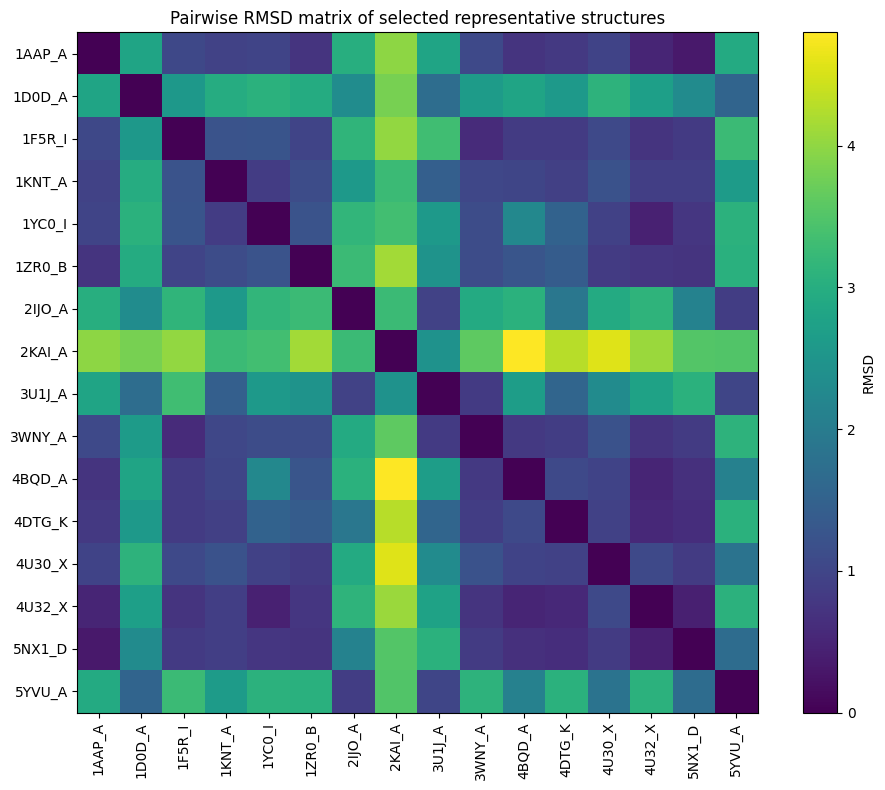

In [301]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(rmsd_matrix.values)

ax.set_xticks(range(len(rmsd_matrix.columns)))
ax.set_yticks(range(len(rmsd_matrix.index)))
ax.set_xticklabels(rmsd_matrix.columns, rotation=90)
ax.set_yticklabels(rmsd_matrix.index)

ax.set_title("Pairwise RMSD matrix of selected representative structures")
fig.colorbar(im, ax=ax, label="RMSD")

plt.tight_layout()
plt.savefig("pairwise_rmsd_heatmap.png", dpi=300)
plt.show()

This cell generates a heatmap of pairwise RMSD values. Lower RMSD values indicate more similar structures.

### Plot TM-score heatmap

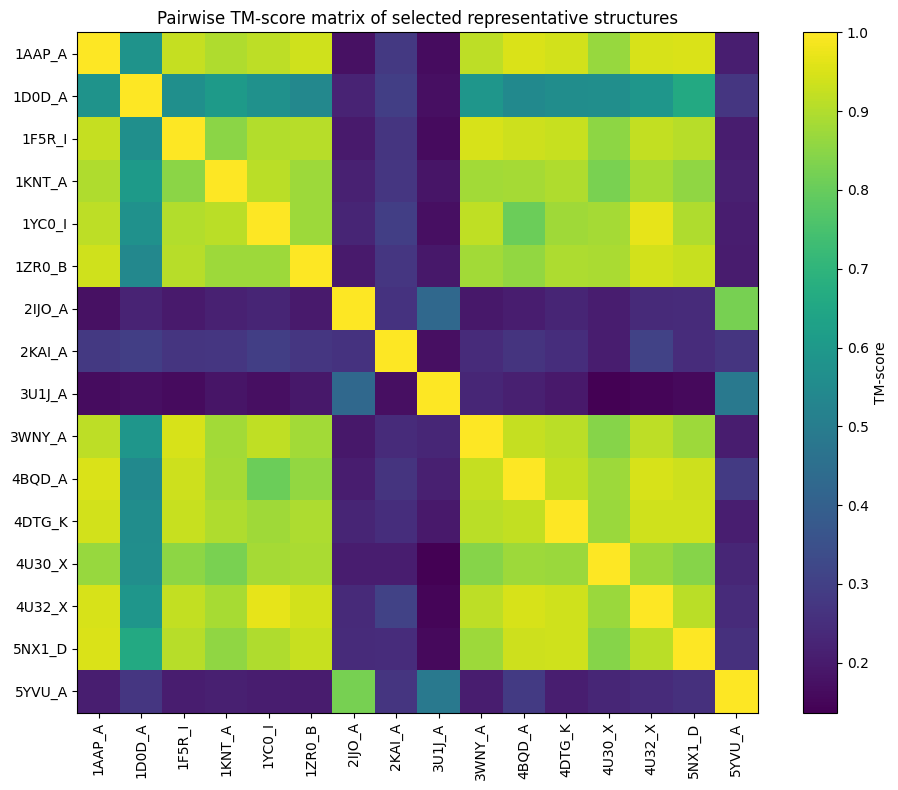

In [302]:
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(tm_matrix.values)

ax.set_xticks(range(len(tm_matrix.columns)))
ax.set_yticks(range(len(tm_matrix.index)))
ax.set_xticklabels(tm_matrix.columns, rotation=90)
ax.set_yticklabels(tm_matrix.index)

ax.set_title("Pairwise TM-score matrix of selected representative structures")
fig.colorbar(im, ax=ax, label="TM-score")

plt.tight_layout()
plt.savefig("pairwise_tm_score_heatmap.png", dpi=300)
plt.show()

This cell generates a heatmap of pairwise TM-scores. Higher TM-score values indicate stronger structural similarity.

### Structural QC summary table

In [303]:
# Remove diagonal values before calculating mean/median statistics
rmsd_no_diag = rmsd_matrix.copy()
tm_no_diag = tm_matrix.copy()

for s in structure_names:
    rmsd_no_diag.loc[s, s] = np.nan
    tm_no_diag.loc[s, s] = np.nan

qc_summary = pd.DataFrame(index=structure_names)

qc_summary["mean_RMSD"] = rmsd_no_diag.mean(axis=1)
qc_summary["median_RMSD"] = rmsd_no_diag.median(axis=1)
qc_summary["max_RMSD"] = rmsd_no_diag.max(axis=1)

qc_summary["mean_TM_score"] = tm_no_diag.mean(axis=1)
qc_summary["median_TM_score"] = tm_no_diag.median(axis=1)
qc_summary["min_TM_score"] = tm_no_diag.min(axis=1)

# Structures with high RMSD and low TM-score are more suspicious
qc_summary = qc_summary.sort_values(
    ["mean_RMSD", "mean_TM_score"],
    ascending=[False, True]
)

qc_summary.to_csv("pairwise_structural_qc_summary.tsv", sep="\t")

qc_summary

,mean_RMSD,median_RMSD,max_RMSD,mean_TM_score,median_TM_score,min_TM_score
2KAI_A,3.778667,3.82,4.80,0.260823,0.26865,0.17238
1D0D_A,2.660667,2.70,3.82,0.489282,0.56231,0.17295
2IJO_A,2.578667,2.94,3.28,0.270820,0.22113,0.17396
5YVU_A,2.450667,2.93,3.50,0.287554,0.22930,0.20082
3U1J_A,2.130000,2.45,3.33,0.214676,0.17295,0.13673
1YC0_I,1.768667,1.25,3.35,0.695077,0.87560,0.17262
1ZR0_B,1.734667,1.22,4.14,0.692887,0.87475,0.19300
1F5R_I,1.712000,1.05,4.03,0.698725,0.89949,0.16162
4BQD_A,1.699333,1.06,4.80,0.703235,0.87227,0.20589
4U30_X,1.648667,1.05,4.57,0.663772,0.84456,0.13673


This cell summarizes the average structural similarity of each representative structure to all others. Structures with high mean RMSD or low mean TM-score may be potential outliers.

### Detect possible structural outliers

In [304]:
# RMSD outlier cutoff using IQR
rmsd_q1 = qc_summary["mean_RMSD"].quantile(0.25)
rmsd_q3 = qc_summary["mean_RMSD"].quantile(0.75)
rmsd_iqr = rmsd_q3 - rmsd_q1
rmsd_cutoff = rmsd_q3 + 1.5 * rmsd_iqr

# TM-score outlier cutoff using IQR
tm_q1 = qc_summary["mean_TM_score"].quantile(0.25)
tm_q3 = qc_summary["mean_TM_score"].quantile(0.75)
tm_iqr = tm_q3 - tm_q1
tm_cutoff = tm_q1 - 1.5 * tm_iqr

potential_outliers = qc_summary[
    (qc_summary["mean_RMSD"] > rmsd_cutoff) |
    (qc_summary["mean_TM_score"] < tm_cutoff)
]

print("RMSD outlier cutoff:", rmsd_cutoff)
print("TM-score outlier cutoff:", tm_cutoff)
print("Potential structural outliers:", len(potential_outliers))

potential_outliers

RMSD outlier cutoff: 3.229666666666666
TM-score outlier cutoff: 0.04224900000000015
Potential structural outliers: 1


,mean_RMSD,median_RMSD,max_RMSD,mean_TM_score,median_TM_score,min_TM_score
2KAI_A,3.778667,3.82,4.8,0.260823,0.26865,0.17238


This cell applies a simple IQR-based rule to flag possible structural outliers. These structures should be inspected manually before deciding whether to remove them.

### Interpretation of structural QC

The RMSD and TM-score heatmaps were used to inspect the structural consistency of the selected representative Kunitz/BPTI domains. Structures showing unusually high mean RMSD or low mean TM-score were considered potential outliers and checked together with the multiple structural alignment. Based on the pairwise RMSD and TM-score analysis, three representative structures showed unusually low structural similarity to the rest of the dataset. These structures were treated as potential outliers and were removed before building the final HMM, in order to obtain a cleaner Kunitz-domain profile.

Chain      | Reason


2IJO_A     short aligned region, cysteine count = 0


3U1J_A     very short aligned region, cysteine count = 0


5YVU_A     short aligned region, cysteine count = 0


2KAI_A     highest mean RMSD, low mean TM-score

In [305]:
from pathlib import Path

outlier_ids = {"2IJO_A", "3U1J_A", "5YVU_A", "2KAI_A"}

with open("chains_list.txt") as f:
    chain_files = [line.strip() for line in f if line.strip()]

clean_chain_files = []

for file in chain_files:
    structure_id = Path(file).stem
    if structure_id not in outlier_ids:
        clean_chain_files.append(file)

with open("chains_list_no_outliers.txt", "w") as out:
    for file in clean_chain_files:
        out.write(file + "\n")

print("Original structures:", len(chain_files))
print("Structures after removing outliers:", len(clean_chain_files))

print("\nRemoved outliers:")
for file in chain_files:
    structure_id = Path(file).stem
    if structure_id in outlier_ids:
        print(structure_id)

Original structures: 16
Structures after removing outliers: 12

Removed outliers:
2IJO_A
2KAI_A
3U1J_A
5YVU_A


After removing the four outlier chains, mTM-align was run again using only the cleaned set of representative structures. This step was necessary because simply deleting sequences from the previous alignment would still keep an alignment influenced by the removed outliers. The recomputed alignment was therefore used for final trimming and HMM construction.

In [306]:
!rm -rf mTM_result_no_outliers
!rm -f alignment_no_outliers.fasta

!mTM-align/src/mTM-align -i chains_list_no_outliers.txt -outdir mTM_result_no_outliers

!cp mTM_result_no_outliers/result.fasta alignment_no_outliers.fasta

!grep "^>" alignment_no_outliers.fasta
!echo "Final alignment sequences:" $(grep "^>" alignment_no_outliers.fasta | wc -l)

output dir: mTM_result_no_outliers

 ***************************************************************
 *                 mTM-align (Version 20180725)                *
 * An algorithm for multiple protein structure alignment (MSTA)*
 * Reference: Dong, et al, Bioinformatics, 34: 1719-1725 (2018)*
 * Please email your comments to: yangjy@nankai.edu.cn         *
 ***************************************************************


------------- Summary of your input -------------
Input 12 structures: 1AAP_A.pdb, 1D0D_A.pdb, 1F5R_I.pdb, 1KNT_A.pdb, 1YC0_I.pdb, 1ZR0_B.pdb, 3WNY_A.pdb, 4BQD_A.pdb, 4DTG_K.pdb, 4U30_X.pdb, 4U32_X.pdb, 5NX1_D.pdb
Average length: 58.4167


------------- Summary of the MSTA  -------------
Lcore: 34
ccRMSD: 0.722795
ccTM-score: 0.592182
Lali: 50.4545
RMSD: 0.967309
TM-score: 0.842587


------------- MSTA  -------------
1AAP_A.pdb	-------------------------V--R-EV-C-SEQAE-----------TGPCRAMISRWYFDVTEGKCAPFFYGG--CG---GNRNNFDTEEYCMAVCG------
1D0D_A.pdb	--------------------

In [307]:
!grep "^>" alignment_no_outliers.fasta | wc -l

12


The pairwise structural QC identified 2IJO_A, 3U1J_A and 5YVU_A as potential structural outliers based on low mean TM-score and/or high RMSD. These structures were removed before the final alignment trimming and HMM construction to obtain a cleaner structure-based seed alignment.

## HMM Construction

We can check it's installation by running one of their functions `hmmbuild`:

In [308]:
!hmmbuild -h

# hmmbuild :: profile HMM construction from multiple sequence alignments
# HMMER 3.3.2 (Nov 2020); http://hmmer.org/
# Copyright (C) 2020 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
Usage: hmmbuild [-options] <hmmfile_out> <msafile>

Basic options:
  -h     : show brief help on version and usage
  -n <s> : name the HMM <s>
  -o <f> : direct summary output to file <f>, not stdout
  -O <f> : resave annotated, possibly modified MSA to file <f>

Options for selecting alphabet rather than guessing it:
  --amino : input alignment is protein sequence data
  --dna   : input alignment is DNA sequence data
  --rna   : input alignment is RNA sequence data

Alternative model construction strategies:
  --fast           : assign cols w/ >= symfrac residues as consensus  [default]
  --hand           : manual construction (requires reference annotation)
  --symfrac <x>    : sets sym f

We can see that `hmmbuild` requires two main arguments:

1. `<hmmfile_out>`, which specifies the name of the output HMM file. In this project, the output file was named `kunitz.hmm`.
2. `<msafile>`, which is the cleaned and trimmed structure-based multiple sequence alignment. In the final analysis, this file was `alignment_clean_trimmed.fasta`.

The cleaned alignment was obtained after removing structural outliers identified during pairwise structural quality control and trimming gap-rich columns.

To build the final HMM, we run:

In [309]:
!ls -lh alignment.fasta
!pwd

-rw-r--r-- 1 root root 3.1K May 14 20:44 alignment.fasta
/content/Kunitz-BPTI-HMM


The cleaned structural alignment was trimmed to remove poorly informative alignment columns. Columns containing only gaps or highly gapped regions were removed before HMM construction, so that the final profile would focus on the conserved Kunitz/BPTI domain core.

In [310]:
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

records = list(SeqIO.parse("alignment_no_outliers.fasta", "fasta"))
seqs = [str(r.seq) for r in records]
aln_len = len(seqs[0])

keep_cols = []

for i in range(aln_len):
    col = [s[i] for s in seqs]
    gap_fraction = sum(x in ["-", "."] for x in col) / len(col)
    if gap_fraction <= 0.50:
        keep_cols.append(i)

trimmed_records = []
for r in records:
    s = str(r.seq)
    trimmed_seq = "".join(s[i] for i in keep_cols)
    trimmed_records.append(SeqRecord(Seq(trimmed_seq), id=r.id, description=""))

SeqIO.write(trimmed_records, "alignment_clean_trimmed.fasta", "fasta")

print("Original alignment length:", aln_len)
print("Trimmed alignment length:", len(keep_cols))
print("Saved: alignment_clean_trimmed.fasta")

Original alignment length: 108
Trimmed alignment length: 56
Saved: alignment_clean_trimmed.fasta


In [311]:
!ls -lh alignment_clean_trimmed.fasta
!head alignment_clean_trimmed.fasta

-rw-r--r-- 1 root root 828 May 14 20:45 alignment_clean_trimmed.fasta
>1AAP_A.pdb
REVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFDTEEYCMAVCG-
>1D0D_A.pdb
Y-RC-I-KP-----GGERAYFRNG-KGGCDSFWICPHT----YYSSYRDCFNACI-
>1F5R_I.pdb
PDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFKSAEDCMRTCGG
>1KNT_A.pdb
TDICKLPKDEGTCRDFILKWYYDPNTKSCARFWYGGCGGNENKFGSQKECEKVCA-
>1YC0_I.pdb
TEDCLASNKVGRCRGSFPRWYYDPTEQICKSFVYGGCLGNKNNYLREEECILACRG


In [312]:
!hmmbuild --amino -n Kunitz_BPTI kunitz.hmm alignment_clean_trimmed.fasta
!grep -E "^(NAME|LENG)" kunitz.hmm

# hmmbuild :: profile HMM construction from multiple sequence alignments
# HMMER 3.3.2 (Nov 2020); http://hmmer.org/
# Copyright (C) 2020 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# input alignment file:             alignment_clean_trimmed.fasta
# output HMM file:                  kunitz.hmm
# name (the single) HMM:            Kunitz_BPTI
# input alignment is asserted as:   protein
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

# idx name                  nseq  alen  mlen eff_nseq re/pos description
#---- -------------------- ----- ----- ----- -------- ------ -----------
1     Kunitz_BPTI             12    56    55     2.09  1.010 

# CPU time: 0.03u 0.00s 00:00:00.03 Elapsed: 00:00:00.03
NAME  Kunitz_BPTI
LENG  55


This file contains the statistical parameters of the HMM, including match states, insert states, delete states, and the matrix containing the transition probabilities. It's a compact representation of the sequence conservation patterns in the Kunitz family.

You'll also like to verify the model with [Skylign](https://skylign.org). Upload your `.hmm` model and generate the logo, it should look like this:

## Model Evaluation

Now that we have our own model, we have to evaluate its performance. To do so, first we need to prepare our evaluation sets.

### Fetching datasets

We're going to fetch protein sequences from Uniprot to create positive and negative datasets for evaluating the HMM.
-   `positive_kunitz.fasta`: Contains reviewed UniProt entries that are part of Pfam PF00014 (Kunitz family).
-   `negative_kunitz.fasta`: Contains reviewed UniProt entries that are not associated with Pfam PF00014.

To prepare these datasets, we can run the following commands:

(**DO NOT RUN**. These downloads take a lot of time so I already did it in advance and saved them in the notebook folder.)

We can count the number of entries retrieved:

In [313]:
!grep ">" positive_kunitz.fasta |wc -l
!grep ">" negative_kunitz.fasta |wc -l

398
574229


## Removal of training-like positive sequences

To make the evaluation more independent, positive UniProt sequences that are highly similar to the PDB-derived representatives used for HMM construction were removed before testing. This avoids evaluating the model on sequences that are almost identical to the training representatives.

BLASTP was used to compare the final cleaned alignment against the positive UniProt dataset. Positive sequences with sequence identity ≥ 95% and alignment length ≥ 50 residues were considered training-like and removed from the positive evaluation set.

In [314]:
from Bio import SeqIO
from Bio.Seq import Seq

ungapped_records = []

for rec in SeqIO.parse("alignment_clean_trimmed.fasta", "fasta"):
    rec.seq = Seq(str(rec.seq).replace("-", ""))
    ungapped_records.append(rec)

SeqIO.write(ungapped_records, "training_representatives_ungapped.fasta", "fasta")

print("Ungapped training representatives:", len(ungapped_records))

Ungapped training representatives: 12


In [315]:
!apt-get -qq update
!apt-get -qq install -y ncbi-blast+

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [316]:
!rm -f positive_kunitz_db.*

!makeblastdb \
    -in positive_kunitz.fasta \
    -dbtype prot \
    -out positive_kunitz_db

!ls -lh positive_kunitz_db.*



Building a new DB, current time: 05/14/2026 20:45:37
New DB name:   /content/Kunitz-BPTI-HMM/positive_kunitz_db
New DB title:  positive_kunitz.fasta
Sequence type: Protein
Keep MBits: T
Maximum file size: 1000000000B
Adding sequences from FASTA; added 398 sequences in 0.0100398 seconds.


-rw-r--r-- 1 root root  20K May 14 20:45 positive_kunitz_db.pdb
-rw-r--r-- 1 root root  65K May 14 20:45 positive_kunitz_db.phr
-rw-r--r-- 1 root root 3.3K May 14 20:45 positive_kunitz_db.pin
-rw-r--r-- 1 root root 4.7K May 14 20:45 positive_kunitz_db.pot
-rw-r--r-- 1 root root  76K May 14 20:45 positive_kunitz_db.psq
-rw-r--r-- 1 root root  16K May 14 20:45 positive_kunitz_db.ptf
-rw-r--r-- 1 root root 1.6K May 14 20:45 positive_kunitz_db.pto


In [317]:
!rm -f training_vs_positive.blast blastp_error.log

!blastp \
    -query training_representatives_ungapped.fasta \
    -db positive_kunitz_db \
    -out training_vs_positive.blast \
    -outfmt 6 \
    2> blastp_error.log

!echo "BLAST errors:"
!cat blastp_error.log

!echo "BLAST output:"
!ls -lh training_vs_positive.blast
!head training_vs_positive.blast

BLAST errors:
BLAST output:
-rw-r--r-- 1 root root 385K May 14 20:45 training_vs_positive.blast
1AAP_A.pdb	sp|P79307|A4_PIG	100.000	55	0	0	1	55	288	342	7.98e-41	133
1AAP_A.pdb	sp|P08592|A4_RAT	100.000	55	0	0	1	55	288	342	8.22e-41	133
1AAP_A.pdb	sp|Q5IS80|A4_PANTR	100.000	55	0	0	1	55	288	342	8.55e-41	133
1AAP_A.pdb	sp|P05067|A4_HUMAN	100.000	55	0	0	1	55	288	342	9.80e-41	133
1AAP_A.pdb	sp|P53601|A4_MACFA	100.000	55	0	0	1	55	288	342	1.04e-40	133
1AAP_A.pdb	sp|Q95241|A4_SAISC	100.000	55	0	0	1	55	288	342	1.13e-40	133
1AAP_A.pdb	sp|Q60495|A4_CAVPO	98.182	55	1	0	1	55	288	342	2.12e-40	132
1AAP_A.pdb	sp|P12023|A4_MOUSE	98.182	55	1	0	1	55	288	342	3.26e-40	131
1AAP_A.pdb	sp|P29216|A4_MACMU	100.000	54	0	0	2	55	1	54	4.95e-39	117
1AAP_A.pdb	sp|P15943|APLP2_RAT	68.519	54	17	0	1	54	309	362	3.06e-29	100


In [318]:
!awk '$3 >= 95 && $4 >= 50 {print $2}' training_vs_positive.blast | sort -u > training_like_positive.ids

!echo "Training-like positive sequences to remove:"
!wc -l training_like_positive.ids
!head training_like_positive.ids

Training-like positive sequences to remove:
17 training_like_positive.ids
sp|O43278|SPIT1_HUMAN
sp|O43291|SPIT2_HUMAN
sp|P00974|BPT1_BOVIN
sp|P02760|AMBP_HUMAN
sp|P05067|A4_HUMAN
sp|P08592|A4_RAT
sp|P10646|TFPI1_HUMAN
sp|P12023|A4_MOUSE
sp|P12111|CO6A3_HUMAN
sp|P29216|A4_MACMU


In [319]:
from Bio import SeqIO
from pathlib import Path

# Input files
positive_fasta = "positive_kunitz.fasta"
training_like_file = "training_like_positive.ids"

# Output files
independent_output = "positive_kunitz_independent.fasta"
removed_output = "positive_training_like_removed.fasta"

# Read training-like IDs
training_like_ids = set()

with open(training_like_file) as f:
    for line in f:
        raw_id = line.strip()
        if raw_id:
            training_like_ids.add(raw_id)

            # If ID format is like sp|P00974|BPT1_BOVIN, also keep accession P00974
            if "|" in raw_id:
                parts = raw_id.split("|")
                if len(parts) > 1:
                    training_like_ids.add(parts[1])

# Separate independent and removed positives
kept_records = []
removed_records = []

for rec in SeqIO.parse(positive_fasta, "fasta"):
    full_id = rec.id
    accession = rec.id.split("|")[1] if "|" in rec.id else rec.id

    if full_id in training_like_ids or accession in training_like_ids:
        removed_records.append(rec)
    else:
        kept_records.append(rec)

# Write new files only
SeqIO.write(kept_records, independent_output, "fasta")
SeqIO.write(removed_records, removed_output, "fasta")

print("Files created:")
print(f"- {independent_output}")
print(f"- {removed_output}")
print()
print("Original positives:", sum(1 for _ in SeqIO.parse(positive_fasta, "fasta")))
print("Removed training-like positives:", len(removed_records))
print("Independent positives:", len(kept_records))

Files created:
- positive_kunitz_independent.fasta
- positive_training_like_removed.fasta

Original positives: 398
Removed training-like positives: 17
Independent positives: 381


In [320]:
from Bio import SeqIO
import random

positive_count = sum(1 for _ in SeqIO.parse("positive_kunitz_independent.fasta", "fasta"))

hard_negatives = []

for rec in SeqIO.parse("negative_kunitz.fasta", "fasta"):
    seq = str(rec.seq).upper()
    length = len(seq)
    cysteine_count = seq.count("C")

    if (
        40 <= length <= 300 and
        cysteine_count >= 4 and
        "X" not in seq
    ):
        hard_negatives.append(rec)

print("Candidate hard negatives:", len(hard_negatives))
print("Independent positives:", positive_count)

random.seed(42)

if len(hard_negatives) >= positive_count:
    hard_negatives_sampled = random.sample(hard_negatives, positive_count)
else:
    hard_negatives_sampled = hard_negatives

SeqIO.write(hard_negatives_sampled, "negative_kunitz_hard.fasta", "fasta")

print("Hard negatives selected:", len(hard_negatives_sampled))

Candidate hard negatives: 73125
Independent positives: 381
Hard negatives selected: 381


Because the evaluation dataset is highly imbalanced, accuracy alone is not the most informative metric. Therefore, MCC, F1-score, sensitivity, specificity and precision were also calculated. MCC was used as the main criterion for threshold selection.

In [321]:
!rm -f positive.search negative.search hard_negative.search
!rm -f positive.tbl negative.tbl hard_negative.tbl
!rm -f positive.match negative.match hard_negative.match

!hmmsearch -Z 1000 --max --tblout positive.tbl kunitz.hmm positive_kunitz_independent.fasta > positive.search

!hmmsearch -Z 1000 --max --tblout negative.tbl kunitz.hmm negative_kunitz.fasta > negative.search

!hmmsearch -Z 1000 --max --tblout hard_negative.tbl kunitz.hmm negative_kunitz_hard.fasta > hard_negative.search

!ls -lh positive.tbl negative.tbl hard_negative.tbl

-rw-r--r-- 1 root root 2.5K May 14 20:47 hard_negative.tbl
-rw-r--r-- 1 root root 1.3M May 14 20:47 negative.tbl
-rw-r--r-- 1 root root  87K May 14 20:45 positive.tbl


In [322]:
!grep -v '^#' positive.tbl | awk 'NF>0 {print $1"\t"$8"\t1"}' > positive.match
!grep -v '^#' negative.tbl | awk 'NF>0 {print $1"\t"$8"\t0"}' > negative.match
!grep -v '^#' hard_negative.tbl | awk 'NF>0 {print $1"\t"$8"\t0"}' > hard_negative.match

!echo "Positive matches:" $(wc -l < positive.match)
!echo "Random negative matches:" $(wc -l < negative.match)
!echo "Hard negative matches:" $(wc -l < hard_negative.match)

Positive matches: 381
Random negative matches: 5017
Hard negative matches: 7


In [323]:
!grep "^>" positive_kunitz_independent.fasta | wc -l
!grep "^>" negative_kunitz.fasta | wc -l

381
574229


In [324]:
# IDs
!grep "^>" positive_kunitz_independent.fasta | awk '{print $1}' | tr -d ">" | sort -u > positive.ids
!grep "^>" negative_kunitz.fasta | awk '{print $1}' | tr -d ">" | sort -u > negative.ids
!grep "^>" negative_kunitz_hard.fasta | awk '{print $1}' | tr -d ">" | sort -u > hard_negative.ids

# Matched IDs
!awk '{print $1}' positive.match | sort -u > positive_match.ids
!awk '{print $1}' negative.match | sort -u > negative_match.ids
!awk '{print $1}' hard_negative.match | sort -u > hard_negative_match.ids

# No-hit IDs
!comm -23 positive.ids positive_match.ids > positive_nohit.ids
!comm -23 negative.ids negative_match.ids > negative_nohit.ids
!comm -23 hard_negative.ids hard_negative_match.ids > hard_negative_nohit.ids

# Assign no-hit E-value = 100
!awk '{print $1"\t100\t1"}' positive_nohit.ids > positive_nohit.match
!awk '{print $1"\t100\t0"}' negative_nohit.ids > negative_nohit.match
!awk '{print $1"\t100\t0"}' hard_negative_nohit.ids > hard_negative_nohit.match

# Build two benchmark files
!cat positive.match positive_nohit.match negative.match negative_nohit.match > all_predictions_random.tsv
!cat positive.match positive_nohit.match hard_negative.match hard_negative_nohit.match > all_predictions_hard.tsv

!echo "Random benchmark:" $(wc -l < all_predictions_random.tsv)
!echo "Hard benchmark:" $(wc -l < all_predictions_hard.tsv)

Random benchmark: 574610
Hard benchmark: 762


In [325]:
import pandas as pd
from math import sqrt

def load_predictions(file):
    data = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=["id", "evalue", "true"]
    )
    data["evalue"] = data["evalue"].astype(float)
    data["true"] = data["true"].astype(int)
    return data

df_random = load_predictions("all_predictions_random.tsv")
df_hard = load_predictions("all_predictions_hard.tsv")

def compute_metrics(data, threshold):
    pred = (data["evalue"] <= threshold).astype(int)
    true = data["true"]

    TP = int(((pred == 1) & (true == 1)).sum())
    TN = int(((pred == 0) & (true == 0)).sum())
    FP = int(((pred == 1) & (true == 0)).sum())
    FN = int(((pred == 0) & (true == 1)).sum())

    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total else 0
    sensitivity = TP / (TP + FN) if (TP + FN) else 0
    specificity = TN / (TN + FP) if (TN + FP) else 0
    precision = TP / (TP + FP) if (TP + FP) else 0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) else 0

    denom = sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc = ((TP * TN) - (FP * FN)) / denom if denom else 0

    return {
        "threshold": threshold,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "accuracy": accuracy,
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "F1": f1,
        "MCC": mcc
    }

In [326]:
!grep "^>" positive_kunitz_independent.fasta | awk '{print $1}' | tr -d ">" | sort -u > positive.ids
!grep "^>" negative_kunitz.fasta | awk '{print $1}' | tr -d ">" | sort -u > negative.ids

!awk '{print $1}' positive.match | sort -u > positive_match.ids
!awk '{print $1}' negative.match | sort -u > negative_match.ids

!comm -23 positive.ids positive_match.ids > positive_nohit.ids
!comm -23 negative.ids negative_match.ids > negative_nohit.ids

!awk '{print $1"\t100\t1"}' positive_nohit.ids > positive_nohit.match
!awk '{print $1"\t100\t0"}' negative_nohit.ids > negative_nohit.match

!cat positive.match positive_nohit.match negative.match negative_nohit.match > all_predictions.tsv

!head all_predictions.tsv
!wc -l all_predictions.tsv

sp|Q868Z9|PPN_DROME	1.3e-17	1
sp|O76840|PPN1_CAEEL	3.7e-19	1
sp|A0A6P8HC43|ATPI1_ACTTE	7.6e-24	1
sp|Q02445|TFPI1_RAT	1.8e-24	1
sp|P19761|TFPI1_RABIT	2.3e-24	1
sp|O54819|TFPI1_MOUSE	1.6e-24	1
sp|P84875|PCPI_SABMA	4e-22	1
sp|P83606|BMTI6_RHIMP	3.7e-22	1
sp|Q03610|YN81_CAEEL	9e-16	1
sp|Q7YRQ8|TFPI2_BOVIN	9.2e-26	1
574610 all_predictions.tsv


In [327]:
df_random.head()

,id,evalue,true
0,sp|Q868Z9|PPN_DROME,1.300000e-17,1
1,sp|O76840|PPN1_CAEEL,3.700000e-19,1
2,sp|A0A6P8HC43|ATPI1_ACTTE,7.600000e-24,1
3,sp|Q02445|TFPI1_RAT,1.800000e-24,1
4,sp|P19761|TFPI1_RABIT,2.300000e-24,1


In [328]:
df_hard.head()

,id,evalue,true
0,sp|Q868Z9|PPN_DROME,1.300000e-17,1
1,sp|O76840|PPN1_CAEEL,3.700000e-19,1
2,sp|A0A6P8HC43|ATPI1_ACTTE,7.600000e-24,1
3,sp|Q02445|TFPI1_RAT,1.800000e-24,1
4,sp|P19761|TFPI1_RABIT,2.300000e-24,1


In [329]:
from Bio import SeqIO
import pandas as pd
import re

def count_fasta_records(file):
    return sum(1 for _ in SeqIO.parse(file, "fasta"))

def count_lines(file):
    with open(file) as f:
        return sum(1 for line in f if line.strip())

def get_hmm_length(hmm_file):
    with open(hmm_file) as f:
        for line in f:
            if line.startswith("LENG"):
                return int(line.split()[1])
    return None

summary_counts = {
    "PDB chains after length filtering": count_fasta_records("pdb_seqs.txt"),
    "MMseqs2 representatives": count_fasta_records("pdb_cluster_rep_seq.fasta"),
    "Downloaded non-empty chains": count_lines("chains_list.txt"),
    "Final alignment sequences": count_fasta_records("alignment_clean_trimmed.fasta"),
    "Final HMM length": get_hmm_length("kunitz.hmm"),
    "SwissProt positives before removing training-like sequences": count_fasta_records("positive_kunitz.fasta"),
    "SwissProt training-like positives removed": count_fasta_records("positive_training_like_removed.fasta"),
    "SwissProt independent positives used for evaluation": count_fasta_records("positive_kunitz_independent.fasta"),
    "SwissProt negatives": count_fasta_records("negative_kunitz.fasta")
}

pd.DataFrame(summary_counts.items(), columns=["Step", "Count"])

,Step,Count
0,PDB chains after length filtering,139
1,MMseqs2 representatives,16
2,Downloaded non-empty chains,16
3,Final alignment sequences,12
4,Final HMM length,55
5,SwissProt positives before removing training-l...,398
6,SwissProt training-like positives removed,17
7,SwissProt independent positives used for evalu...,381
8,SwissProt negatives,574229


### Final threshold comparison

In [330]:
# Rebuild threshold optimization table for the hard benchmark

thresholds = [1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-15, 1e-20]

threshold_results_hard = pd.DataFrame([
    compute_metrics(df_hard, threshold)
    for threshold in thresholds
])

threshold_results_hard

,threshold,TP,TN,FP,FN,accuracy,sensitivity_recall,specificity,precision,F1,MCC
0,1.000000e+00,381,378,3,0,0.996063,1.000000,0.992126,0.992188,0.996078,0.992157
1,1.000000e-01,381,379,2,0,0.997375,1.000000,0.994751,0.994778,0.997382,0.994764
2,1.000000e-02,380,380,1,1,0.997375,0.997375,0.997375,0.997375,0.997375,0.994751
3,1.000000e-03,379,380,1,2,0.996063,0.994751,0.997375,0.997368,0.996058,0.992129
4,1.000000e-04,377,380,1,4,0.993438,0.989501,0.997375,0.997354,0.993412,0.986907
5,1.000000e-05,376,380,1,5,0.992126,0.986877,0.997375,0.997347,0.992084,0.984306
6,1.000000e-06,374,381,0,7,0.990814,0.981627,1.000000,1.000000,0.990728,0.981793
7,1.000000e-07,374,381,0,7,0.990814,0.981627,1.000000,1.000000,0.990728,0.981793
8,1.000000e-08,374,381,0,7,0.990814,0.981627,1.000000,1.000000,0.990728,0.981793
9,1.000000e-09,373,381,0,8,0.989501,0.979003,1.000000,1.000000,0.989390,0.979219


In [331]:
# Rebuild threshold optimization table for the random benchmark

threshold_results_random = pd.DataFrame([
    compute_metrics(df_random, threshold)
    for threshold in thresholds
])

threshold_results_random

,threshold,TP,TN,FP,FN,accuracy,sensitivity_recall,specificity,precision,F1,MCC
0,1.000000e+00,381,574038,191,0,0.999668,1.000000,0.999667,0.666084,0.799580,0.816004
1,1.000000e-01,381,574197,32,0,0.999944,1.000000,0.999944,0.922518,0.959698,0.960451
2,1.000000e-02,380,574213,16,1,0.999970,0.997375,0.999972,0.959596,0.978121,0.978289
3,1.000000e-03,379,574219,10,2,0.999979,0.994751,0.999983,0.974293,0.984416,0.984458
4,1.000000e-04,377,574221,8,4,0.999979,0.989501,0.999986,0.979221,0.984334,0.984337
5,1.000000e-05,376,574223,6,5,0.999981,0.986877,0.999990,0.984293,0.985583,0.985574
6,1.000000e-06,374,574227,2,7,0.999984,0.981627,0.999997,0.994681,0.988111,0.988125
7,1.000000e-07,374,574228,1,7,0.999986,0.981627,0.999998,0.997333,0.989418,0.989442
8,1.000000e-08,374,574229,0,7,0.999988,0.981627,1.000000,1.000000,0.990728,0.990765
9,1.000000e-09,373,574229,0,8,0.999986,0.979003,1.000000,1.000000,0.989390,0.989439


In [332]:
# Define two benchmark-specific optimized thresholds

best_hard = threshold_results_hard.sort_values(
    ["MCC", "F1", "sensitivity_recall", "specificity"],
    ascending=False
).iloc[0]

optimized_threshold = best_hard["threshold"]
optimized_threshold_hard = optimized_threshold

best_random = threshold_results_random.sort_values(
    ["MCC", "F1", "sensitivity_recall", "specificity"],
    ascending=False
).iloc[0]

optimized_threshold_random = best_random["threshold"]

print("MCC-optimized threshold on hard benchmark:", optimized_threshold_hard)
print("MCC-optimized threshold on random benchmark:", optimized_threshold_random)

MCC-optimized threshold on hard benchmark: 0.1
MCC-optimized threshold on random benchmark: 1e-08


## Robustness Analysis: Iterative Cross-Validation

To evaluate whether the selected E-value threshold was stable, an iterative cross-validation analysis was performed. In each iteration, the positive and negative datasets were randomly split into two halves. The best threshold was selected on one half by maximizing MCC and then tested on the other half.

This analysis checks whether the model performance depends strongly on a specific random split of the evaluation dataset.

### functions metrics

In [333]:
import pandas as pd
from math import sqrt

# Use hard benchmark predictions, not the PDB report dataframe
df_eval = df_hard.copy()

df_eval["evalue"] = pd.to_numeric(df_eval["evalue"], errors="coerce")
df_eval["true"] = pd.to_numeric(df_eval["true"], errors="coerce")
df_eval = df_eval.dropna(subset=["evalue", "true"])
df_eval["true"] = df_eval["true"].astype(int)

print("Evaluation dataframe columns:", df_eval.columns.tolist())
print(df_eval["true"].value_counts())

Evaluation dataframe columns: ['id', 'evalue', 'true']
true
1    381
0    381
Name: count, dtype: int64


In [334]:
import pandas as pd
from math import sqrt

# Reload df from the prediction file, do NOT use df.copy()
df = pd.read_csv(
    "all_predictions_hard.tsv",
    sep="\t",
    header=None
)

print("Raw shape:", df.shape)
print("Raw columns:", df.columns.tolist())
print(df.head())

# Keep only the first 3 columns: id, evalue, true
df = df.iloc[:, :3]
df.columns = ["id", "evalue", "true"]

df["evalue"] = pd.to_numeric(df["evalue"], errors="coerce")
df["true"] = pd.to_numeric(df["true"], errors="coerce")

df = df.dropna(subset=["id", "evalue", "true"])
df["true"] = df["true"].astype(int)

print("Clean columns:", df.columns.tolist())
print(df.head())
print(df["true"].value_counts())

thresholds = [1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-15, 1e-20]

def calculate_metrics(data, threshold, evalue_col="evalue"):
    pred = (data[evalue_col] <= threshold).astype(int)
    true = data["true"].astype(int)

    TP = int(((pred == 1) & (true == 1)).sum())
    TN = int(((pred == 0) & (true == 0)).sum())
    FP = int(((pred == 1) & (true == 0)).sum())
    FN = int(((pred == 0) & (true == 1)).sum())

    total = TP + TN + FP + FN

    accuracy = (TP + TN) / total if total else 0
    sensitivity = TP / (TP + FN) if (TP + FN) else 0
    specificity = TN / (TN + FP) if (TN + FP) else 0
    precision = TP / (TP + FP) if (TP + FP) else 0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) else 0

    denom = sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc = ((TP * TN) - (FP * FN)) / denom if denom else 0

    return {
        "threshold": threshold,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "accuracy": accuracy,
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "F1": f1,
        "MCC": mcc
    }

def find_best_threshold(data, thresholds, evalue_col="evalue"):
    results = pd.DataFrame([
        calculate_metrics(data, threshold, evalue_col=evalue_col)
        for threshold in thresholds
    ])

    best_row = results.sort_values(
        ["MCC", "F1", "sensitivity_recall", "specificity"],
        ascending=False
    ).iloc[0]

    best_threshold = best_row["threshold"]
    return best_threshold, results


n_iterations = 10
cv_results = []

positive_df = df[df["true"] == 1].copy()
negative_df = df[df["true"] == 0].copy()

print("Positive sequences:", len(positive_df))
print("Negative sequences:", len(negative_df))

for i in range(n_iterations):
    pos_shuffled = positive_df.sample(frac=1, random_state=i).reset_index(drop=True)
    neg_shuffled = negative_df.sample(frac=1, random_state=i).reset_index(drop=True)

    pos_half = len(pos_shuffled) // 2
    neg_half = len(neg_shuffled) // 2

    set1 = pd.concat([
        pos_shuffled.iloc[:pos_half],
        neg_shuffled.iloc[:neg_half]
    ]).sample(frac=1, random_state=i).reset_index(drop=True)

    set2 = pd.concat([
        pos_shuffled.iloc[pos_half:],
        neg_shuffled.iloc[neg_half:]
    ]).sample(frac=1, random_state=i).reset_index(drop=True)

    best_thr_1, train_results_1 = find_best_threshold(set1, thresholds, evalue_col="evalue")
    test_metrics_1 = calculate_metrics(set2, best_thr_1, evalue_col="evalue")
    test_metrics_1["iteration"] = i + 1
    test_metrics_1["train_set"] = "set1"
    test_metrics_1["test_set"] = "set2"
    test_metrics_1["selected_threshold"] = best_thr_1

    best_thr_2, train_results_2 = find_best_threshold(set2, thresholds, evalue_col="evalue")
    test_metrics_2 = calculate_metrics(set1, best_thr_2, evalue_col="evalue")
    test_metrics_2["iteration"] = i + 1
    test_metrics_2["train_set"] = "set2"
    test_metrics_2["test_set"] = "set1"
    test_metrics_2["selected_threshold"] = best_thr_2

    cv_results.append(test_metrics_1)
    cv_results.append(test_metrics_2)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

Raw shape: (762, 3)
Raw columns: [0, 1, 2]
                           0             1  2
0        sp|Q868Z9|PPN_DROME  1.300000e-17  1
1       sp|O76840|PPN1_CAEEL  3.700000e-19  1
2  sp|A0A6P8HC43|ATPI1_ACTTE  7.600000e-24  1
3        sp|Q02445|TFPI1_RAT  1.800000e-24  1
4      sp|P19761|TFPI1_RABIT  2.300000e-24  1
Clean columns: ['id', 'evalue', 'true']
                          id        evalue  true
0        sp|Q868Z9|PPN_DROME  1.300000e-17     1
1       sp|O76840|PPN1_CAEEL  3.700000e-19     1
2  sp|A0A6P8HC43|ATPI1_ACTTE  7.600000e-24     1
3        sp|Q02445|TFPI1_RAT  1.800000e-24     1
4      sp|P19761|TFPI1_RABIT  2.300000e-24     1
true
1    381
0    381
Name: count, dtype: int64
Positive sequences: 381
Negative sequences: 381


,threshold,TP,TN,FP,FN,accuracy,sensitivity_recall,specificity,precision,F1,MCC,iteration,train_set,test_set,selected_threshold
0,1.00,191,189,2,0,0.994764,1.000000,0.989529,0.989637,0.994792,0.989583,1,set1,set2,1.00
1,0.10,190,189,1,0,0.997368,1.000000,0.994737,0.994764,0.997375,0.994751,1,set2,set1,0.10
2,1.00,191,189,2,0,0.994764,1.000000,0.989529,0.989637,0.994792,0.989583,2,set1,set2,1.00
3,0.01,189,189,1,1,0.994737,0.994737,0.994737,0.994737,0.994737,0.989474,2,set2,set1,0.01
4,0.10,191,189,2,0,0.994764,1.000000,0.989529,0.989637,0.994792,0.989583,3,set1,set2,0.10
5,1.00,190,189,1,0,0.997368,1.000000,0.994737,0.994764,0.997375,0.994751,3,set2,set1,1.00
6,1.00,191,188,3,0,0.992147,1.000000,0.984293,0.984536,0.992208,0.984415,4,set1,set2,1.00
7,0.10,190,190,0,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4,set2,set1,0.10
8,1.00,191,189,2,0,0.994764,1.000000,0.989529,0.989637,0.994792,0.989583,5,set1,set2,1.00
9,0.10,190,189,1,0,0.997368,1.000000,0.994737,0.994764,0.997375,0.994751,5,set2,set1,0.10


In [335]:
iterative_cv_summary = cv_results_df[
    ["selected_threshold", "accuracy", "sensitivity_recall", "specificity", "precision", "F1", "MCC"]
].agg(["mean", "std"])

iterative_cv_summary

,selected_threshold,accuracy,sensitivity_recall,specificity,precision,F1,MCC
mean,0.496000,0.995936,0.999474,0.992397,0.992468,0.995953,0.991907
std,0.468473,0.001793,0.001620,0.003968,0.003911,0.001780,0.003560


Make final confusion matrix:

In [336]:
final_metrics_comparison = pd.DataFrame([
    {
        "threshold_type": "optimized_on_hard",
        "benchmark": "random_negative",
        **compute_metrics(df_random, optimized_threshold)
    },
    {
        "threshold_type": "optimized_on_hard",
        "benchmark": "hard_negative",
        **compute_metrics(df_hard, optimized_threshold)
    },
    {
        "threshold_type": "optimized_on_random",
        "benchmark": "random_negative",
        **compute_metrics(df_random, optimized_threshold_random)
    },
    {
        "threshold_type": "optimized_on_random",
        "benchmark": "hard_negative",
        **compute_metrics(df_hard, optimized_threshold_random)
    }
])

final_metrics_comparison

,threshold_type,benchmark,threshold,TP,TN,FP,FN,accuracy,sensitivity_recall,specificity,precision,F1,MCC
0,optimized_on_hard,random_negative,1.000000e-01,381,574197,32,0,0.999944,1.000000,0.999944,0.922518,0.959698,0.960451
1,optimized_on_hard,hard_negative,1.000000e-01,381,379,2,0,0.997375,1.000000,0.994751,0.994778,0.997382,0.994764
2,optimized_on_random,random_negative,1.000000e-08,374,574229,0,7,0.999988,0.981627,1.000000,1.000000,0.990728,0.990765
3,optimized_on_random,hard_negative,1.000000e-08,374,381,0,7,0.990814,0.981627,1.000000,1.000000,0.990728,0.981793


### Benchmark-specific threshold comparison

Two benchmark-specific thresholds were reported for the final evaluation. The threshold 1e-1 was selected as the MCC-optimized threshold on the hard-negative benchmark. This threshold gave the best overall performance on the hard benchmark, with high sensitivity and only a small number of false positives.

The threshold was also optimized on the random-negative benchmark. The best threshold on the random benchmark was 1e-8. This threshold is more stringent than the hard-optimized threshold and produced no false positives in both benchmarks, although it introduced seven false negatives. Therefore, 1e-1 represents the hard-benchmark optimized threshold, while 1e-8 represents the random-benchmark optimized and more specificity-focused threshold.

In [337]:
# Confusion matrices for both final thresholds on the hard benchmark

optimized_hard_metrics = compute_metrics(df_hard, optimized_threshold)
conservative_hard_metrics = compute_metrics(df_hard, optimized_threshold_random)

confusion_matrix_optimized_hard = pd.DataFrame(
    [
        [optimized_hard_metrics["TN"], optimized_hard_metrics["FP"]],
        [optimized_hard_metrics["FN"], optimized_hard_metrics["TP"]]
    ],
    index=["True negative class", "True positive class"],
    columns=["Predicted negative", "Predicted positive"]
)

confusion_matrix_conservative_hard = pd.DataFrame(
    [
        [conservative_hard_metrics["TN"], conservative_hard_metrics["FP"]],
        [conservative_hard_metrics["FN"], conservative_hard_metrics["TP"]]
    ],
    index=["True negative class", "True positive class"],
    columns=["Predicted negative", "Predicted positive"]
)

print("Confusion matrix - optimized threshold on hard benchmark:")
display(confusion_matrix_optimized_hard)

print("Confusion matrix - conservative threshold on hard benchmark:")
display(confusion_matrix_conservative_hard)

Confusion matrix - optimized threshold on hard benchmark:


,Predicted negative,Predicted positive
True negative class,379,2
True positive class,0,381


Confusion matrix - conservative threshold on hard benchmark:


,Predicted negative,Predicted positive
True negative class,381,0
True positive class,7,374


The two-fold validation gives a simple train/test threshold check, while the iterative cross-validation repeats this process over multiple random splits to assess robustness.

## Skylign

Uploaded files: ['7f275dc1-d64e-4402-b97a-6f2912f06456 (3).png', 'me (3).png']


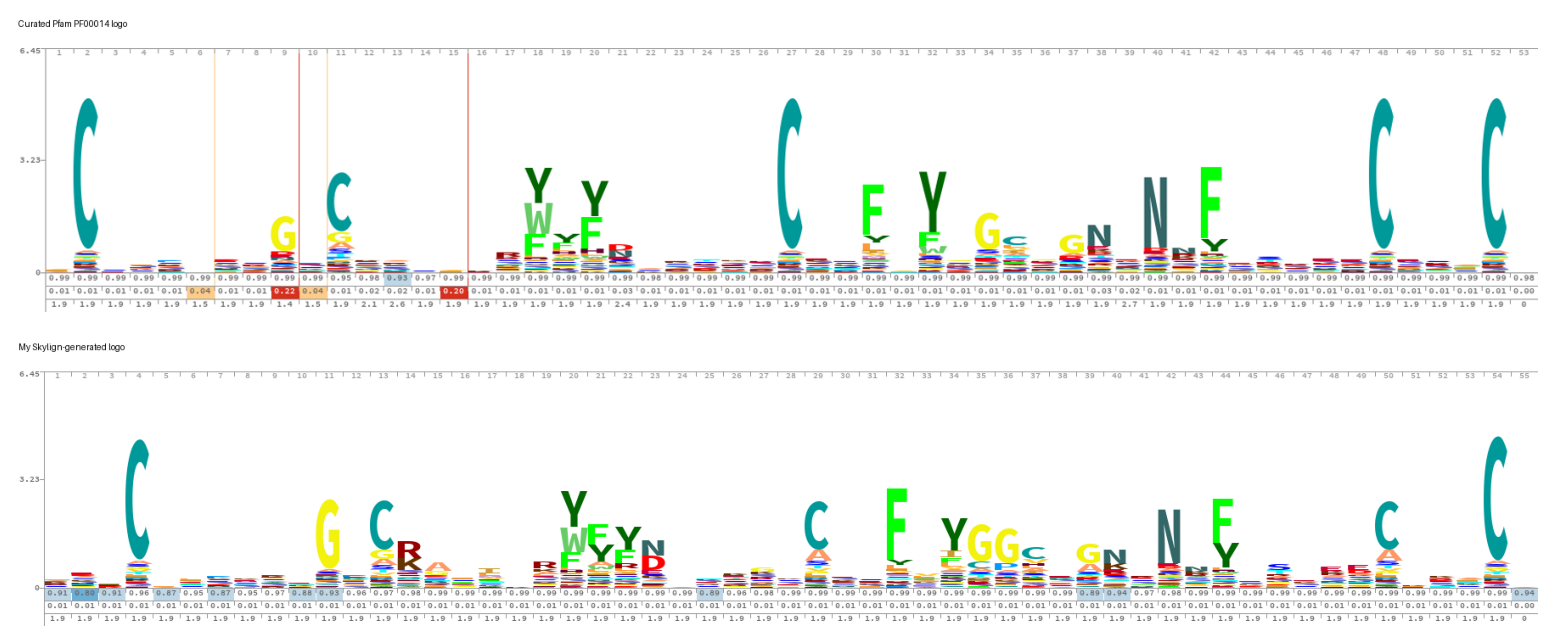

In [338]:
from google.colab import files
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os

# Remove previous output if it exists
output_name = "kunitz_logo_comparison.png"
if os.path.exists(output_name):
    os.remove(output_name)

# Upload exactly two images
uploaded = files.upload()

# Hide upload preview/output
clear_output(wait=True)

image_files = list(uploaded.keys())

if len(image_files) != 2:
    raise ValueError("Please upload exactly 2 images.")

print("Uploaded files:", image_files)

# Open images
img1 = Image.open(image_files[0]).convert("RGB")
img2 = Image.open(image_files[1]).convert("RGB")

# Resize both images to the same width
target_width = max(img1.width, img2.width)

def resize_to_width(img, width):
    ratio = width / img.width
    new_height = int(img.height * ratio)
    return img.resize((width, new_height))

img1_resized = resize_to_width(img1, target_width)
img2_resized = resize_to_width(img2, target_width)

# Add labels
label_height = 45
gap = 25

total_height = label_height + img1_resized.height + gap + label_height + img2_resized.height
combined = Image.new("RGB", (target_width, total_height), "white")

draw = ImageDraw.Draw(combined)

# First image label
draw.text((10, 10), "Curated Pfam PF00014 logo", fill="black")
combined.paste(img1_resized, (0, label_height))

# Second image label
second_y = label_height + img1_resized.height + gap
draw.text((10, second_y + 10), "My Skylign-generated logo", fill="black")
combined.paste(img2_resized, (0, second_y + label_height))

# Save final image
combined.save(output_name)

# Show ONLY the final combined image
plt.figure(figsize=(20, 8))
plt.imshow(combined)
plt.axis("off")
plt.show()

### Comparison with the curated Pfam PF00014 logo

The figure below compares the curated Pfam PF00014 Kunitz/BPTI sequence logo with the sequence logo generated from my own HMM using Skylign. In the corrected interpretation, the upper logo corresponds to the curated Pfam PF00014 logo, while the lower logo corresponds to my Skylign-generated HMM logo.

Some differences can be observed between the two logos, including slight shifts in residue positions and differences in residue conservation strength. These differences are expected because my HMM was built from a smaller and less curated structural dataset, while the Pfam PF00014 logo is based on a manually curated profile HMM built from a larger family alignment.

Overall, the comparison suggests that my HMM successfully captures the main conserved features of the Kunitz/BPTI domain, especially the characteristic cysteine pattern. The conserved cysteine positions observed in both logos are consistent with the disulfide-rich Kunitz/BPTI fold.

## False Positive and False Negative

In [339]:
# Add predictions for both thresholds to the hard benchmark dataframe

df_hard_analysis = df_hard.copy()

df_hard_analysis["pred_optimized"] = (
    df_hard_analysis["evalue"] <= optimized_threshold
).astype(int)

df_hard_analysis["pred_conservative"] = (
    df_hard_analysis["evalue"] <= optimized_threshold_random
).astype(int)

# Optimized threshold FP/FN
false_positives_optimized = df_hard_analysis[
    (df_hard_analysis["true"] == 0) & (df_hard_analysis["pred_optimized"] == 1)
].sort_values("evalue")

false_negatives_optimized = df_hard_analysis[
    (df_hard_analysis["true"] == 1) & (df_hard_analysis["pred_optimized"] == 0)
].sort_values("evalue")

# Conservative threshold FP/FN
false_positives_conservative = df_hard_analysis[
    (df_hard_analysis["true"] == 0) & (df_hard_analysis["pred_conservative"] == 1)
].sort_values("evalue")

false_negatives_conservative = df_hard_analysis[
    (df_hard_analysis["true"] == 1) & (df_hard_analysis["pred_conservative"] == 0)
].sort_values("evalue")

print("Optimized threshold false positives:", len(false_positives_optimized))
print("Optimized threshold false negatives:", len(false_negatives_optimized))

print("Conservative threshold false positives:", len(false_positives_conservative))
print("Conservative threshold false negatives:", len(false_negatives_conservative))

Optimized threshold false positives: 2
Optimized threshold false negatives: 0
Conservative threshold false positives: 0
Conservative threshold false negatives: 7


In [340]:
print("False negatives - optimized threshold:")
display(false_negatives_optimized)

print("False negatives - conservative threshold:")
display(false_negatives_conservative)

False negatives - optimized threshold:


,id,evalue,true,pred_optimized,pred_conservative


False negatives - conservative threshold:


,id,evalue,true,pred_optimized,pred_conservative
375,sp|Q11101|YL15_CAEEL,0.000006,1,1,0
376,sp|P86963|KCP2_PINMA,0.000008,1,1,0
339,sp|Q8MVC4|TFPIL_IXOSC,0.000032,1,1,0
377,sp|O62247|BLI5_CAEEL,0.000170,1,1,0
378,sp|Q8WPG5|KUNI_ORNKA,0.000270,1,1,0
379,sp|D3GGZ8|BLI5_HAECO,0.004600,1,1,0
380,sp|A0A1Q1NL17|HA11_HYAAI,0.059000,1,1,0


In [341]:
print("False positives - optimized threshold:")
display(false_positives_optimized)

print("False positives - conservative threshold:")
display(false_positives_conservative)

False positives - optimized threshold:


,id,evalue,true,pred_optimized,pred_conservative
381,sp|Q09JW3|KUNP2_ARGMO,0.000006,0,1,0
382,sp|P67431|NEMR_ECOL6,0.089000,0,1,0


False positives - conservative threshold:


,id,evalue,true,pred_optimized,pred_conservative


## Save

In [342]:
threshold_results_hard.head()

,threshold,TP,TN,FP,FN,accuracy,sensitivity_recall,specificity,precision,F1,MCC
0,1.0000,381,378,3,0,0.996063,1.000000,0.992126,0.992188,0.996078,0.992157
1,0.1000,381,379,2,0,0.997375,1.000000,0.994751,0.994778,0.997382,0.994764
2,0.0100,380,380,1,1,0.997375,0.997375,0.997375,0.997375,0.997375,0.994751
3,0.0010,379,380,1,2,0.996063,0.994751,0.997375,0.997368,0.996058,0.992129
4,0.0001,377,380,1,4,0.993438,0.989501,0.997375,0.997354,0.993412,0.986907


In [345]:
threshold_results_hard.to_csv(
    "threshold_optimization_results_hard.tsv",
    sep="\t",
    index=False
)

threshold_results_random.to_csv(
    "threshold_optimization_results_random.tsv",
    sep="\t",
    index=False
)

final_metrics_comparison.to_csv(
    "final_metrics_benchmark_specific_thresholds.tsv",
    sep="\t",
    index=False
)

confusion_matrix_optimized_hard.to_csv(
    "final_confusion_matrix_hard_optimized_threshold.tsv",
    sep="\t"
)

confusion_matrix_conservative_hard.to_csv(
    "final_confusion_matrix_hard_conservative_threshold.tsv",
    sep="\t"
)

false_positives_optimized.to_csv(
    "false_positives_hard_optimized_threshold.tsv",
    sep="\t",
    index=False
)

false_negatives_optimized.to_csv(
    "false_negatives_hard_optimized_threshold.tsv",
    sep="\t",
    index=False
)

false_positives_conservative.to_csv(
    "false_positives_hard_conservative_threshold.tsv",
    sep="\t",
    index=False
)

false_negatives_conservative.to_csv(
    "false_negatives_hard_conservative_threshold.tsv",
    sep="\t",
    index=False
)

cv_results_df.to_csv("iterative_cross_validation_results_hard.tsv", sep="\t", index=False)
iterative_cv_summary.to_csv("iterative_cross_validation_summary_hard.tsv", sep="\t")

print("Saved final result files for optimized and conservative threshold analyses.")

Saved final result files for optimized and conservative threshold analyses.


In [346]:
print("Threshold optimized on hard benchmark:", optimized_threshold)
display(final_metrics_comparison[
    final_metrics_comparison["threshold_type"] == "optimized_on_hard"
])

print("Threshold optimized on random benchmark:", optimized_threshold_random)
display(final_metrics_comparison[
    final_metrics_comparison["threshold_type"] == "optimized_on_random"
])

Threshold optimized on hard benchmark: 0.1


,threshold_type,benchmark,threshold,TP,TN,FP,FN,accuracy,sensitivity_recall,specificity,precision,F1,MCC
0,optimized_on_hard,random_negative,0.1,381,574197,32,0,0.999944,1.0,0.999944,0.922518,0.959698,0.960451
1,optimized_on_hard,hard_negative,0.1,381,379,2,0,0.997375,1.0,0.994751,0.994778,0.997382,0.994764


Threshold optimized on random benchmark: 1e-08


,threshold_type,benchmark,threshold,TP,TN,FP,FN,accuracy,sensitivity_recall,specificity,precision,F1,MCC
2,optimized_on_random,random_negative,1.000000e-08,374,574229,0,7,0.999988,0.981627,1.0,1.0,0.990728,0.990765
3,optimized_on_random,hard_negative,1.000000e-08,374,381,0,7,0.990814,0.981627,1.0,1.0,0.990728,0.981793


On the hard benchmark, using the MCC-optimized threshold of 1e-1, the model produced two false positives and no false negatives, while maintaining high F1-score and MCC. This indicates that the HMM is highly sensitive and remains robust even under more challenging evaluation conditions.

In summary, the initial filtering followed the assignment criterion of 45 ≤ Polymer Entity Sequence Length ≤ 80. After removing exact duplicate entries, 139 PDB-derived sequences were retained. MMseqs2 clustering produced 16 representative chains. Four problematic representatives, 2IJO_A, 3U1J_A, 5YVU_A and 2KAI_A, were removed after domain-level and structural quality control. The structural alignment was then recomputed using the remaining 12 representative chains and used to build the final Kunitz_BPTI HMM.

For evaluation, 17 training-like positive UniProt sequences were removed using BLASTP, resulting in 381 independent positive sequences. The model was evaluated using both a random-negative benchmark and a hard-negative benchmark.

Two benchmark-specific thresholds were reported. The MCC-optimized threshold on the hard benchmark was 1e-1, which produced two false positives and no false negatives on the hard benchmark. The MCC-optimized threshold on the random benchmark was 1e-8; this more stringent threshold produced no false positives in either benchmark, but introduced seven false negatives. This comparison illustrates the trade-off between sensitivity and specificity and shows that threshold choice depends on the benchmark used for optimization.

Main generated files:

- pdb_seqs.txt: filtered PDB-derived Kunitz sequences
- pdb_cluster_rep_seq.fasta: MMseqs2 representative sequences
- pdb_id.rep: representative PDB:chain identifiers
- chains_list_no_outliers.txt: final cleaned structural representatives
- alignment_clean_trimmed.fasta: final cleaned and trimmed alignment
- kunitz.hmm: final Kunitz_BPTI HMM

- positive_kunitz_independent.fasta: independent positive evaluation set after BLASTP filtering
- training_like_positive.ids: UniProt positive sequences removed because of high similarity to the PDB-derived training representatives

- threshold_optimization_results_hard.tsv: threshold evaluation results for the hard-negative benchmark
- threshold_optimization_results_random.tsv: threshold evaluation results for the random-negative benchmark
- final_metrics_benchmark_specific_thresholds.tsv: comparison of benchmark-specific optimized thresholds on the random-negative and hard-negative benchmarks

- final_confusion_matrix_hard_optimized_threshold.tsv: confusion matrix on the hard benchmark using the hard-benchmark optimized threshold
- final_confusion_matrix_hard_conservative_threshold.tsv: confusion matrix on the hard benchmark using the random-benchmark optimized, more specificity-focused threshold

- false_positives_hard_optimized_threshold.tsv: false positive predictions on the hard benchmark using the hard-benchmark optimized threshold
- false_negatives_hard_optimized_threshold.tsv: false negative predictions on the hard benchmark using the hard-benchmark optimized threshold
- false_positives_hard_conservative_threshold.tsv: false positive predictions on the hard benchmark using the random-benchmark optimized, more specificity-focused threshold
- false_negatives_hard_conservative_threshold.tsv: false negative predictions on the hard benchmark using the random-benchmark optimized, more specificity-focused threshold

- iterative_cross_validation_results_hard.tsv: detailed metrics for each iterative cross-validation run on the hard benchmark
- iterative_cross_validation_summary_hard.tsv: mean and standard deviation of iterative cross-validation metrics on the hard benchmark